# Trabalho Prático de Mineração de Dados — Fase 2
## Utilização de LLMs e Análise Comparativa com Diretrizes de IA Responsável

**Disciplina:** Mineração de Dados  
**Grupo:** 
Davi Oliveira Sad - 2023096043 <br>
Gabrielly Xavier dos Santos - 2024023724 <br>
Júlia Luíza Costa de Toledo - 2024008431 <br>
Rafael Vinicius de Sant’Ana Mathias - 2023087834 <br> 
**Dataset:** Mushroom    
**Tarefa de mineração:** Classificação   
**Data da entrega:** 14/06/2026  

---

## Objetivo deste notebook

Este notebook documenta a Fase 2 do Trabalho Prático. O objetivo é usar uma ou mais LLMs como apoio à construção da solução de mineração de dados e comparar duas trilhas de interação:

- **Trilha A — baseline:** interação com a LLM sem explicitar diretrizes de IA responsável;
- **Trilha B — guiada:** interação com a LLM explicitando as diretrizes de IA responsável escolhidas pelo grupo.

O foco não é apenas mostrar prompts e respostas. O grupo deve analisar criticamente se a explicitação das diretrizes levou a diferenças concretas na solução proposta, por exemplo em:

- escolha de algoritmos;
- tratamento dos dados;
- seleção de atributos;
- definição de parâmetros;
- métricas de avaliação;
- interpretabilidade;
- privacidade;
- análise de viés;
- custo computacional;
- qualidade da documentação.

> **Importante:** este notebook é um modelo de estrutura. Ele contém exemplos, placeholders e código genérico. O grupo deve substituir os campos indicados por informações reais do seu dataset, das interações com LLMs e dos experimentos efetivamente realizados.


# Como usar este notebook

Este notebook foi organizado seguindo a estrutura esperada para a Fase 2:

1. **Business Understanding**
2. **Data Understanding & Data Preparation**
3. **Modeling**
4. **Evaluation**
5. **Checklist final**

Ao longo do notebook, os trechos marcados entre colchetes, como `[INSERIR LINK DA CONVERSA]`, devem ser preenchidos pelo grupo.

## Diferença entre exemplo e entrega real

- Células de **exemplo** mostram como organizar a entrega.
- Células com **placeholders** indicam pontos que devem ser preenchidos.
- Células de **código** são genéricas e podem precisar de adaptação ao dataset.
- Nenhum resultado experimental deve ser inventado.
- Toda conclusão empírica deve estar apoiada em uma tabela, gráfico ou execução de código.


# 0. Controle da entrega e rastreabilidade

Esta seção registra informações mínimas para tornar o trabalho rastreável e auditável.

| Item | Valor |
|---|---|
| Nome do dataset | Mushroom |
| Link público do dataset |https://archive.ics.uci.edu/dataset/73/mushroom |
| Número de linhas | 8.124 |
| Número de colunas | 22 |
| Tarefa de mineração | Classificação |
| LLM usada na Trilha A | Google Gemini |
| LLM usada na Trilha B | Google Gemini |
| Link da conversa — Trilha A | [SESSÃO1](https://gemini.google.com/share/b1034394d755); [SESSÃO2](); [SESSÃO3]() |
| Link da conversa — Trilha B | [SESSÃO1](); [SESSÂO2](); [SESSÂO3]() |

## Diretrizes de IA responsável escolhidas

| Diretriz | Justificativa da escolha | Como será explicitada na Trilha B |
|---|---|---|
| Segurança, confiabilidade e robustez | O problema possui custo de erro assimétrico, pois um falso negativo pode expor pessoas ao risco de intoxicação. Por isso, a solução precisa priorizar redução de erros críticos e comportamento consistente do modelo. | A Trilha B solicitará foco explícito na classe venenosa, uso de métricas como recall e F1 para a classe de maior risco, além de sugestões de pesos de classe, validação estratificada e tratamento cuidadoso dos dados faltantes. |
| Transparência e explicabilidade | A decisão precisa ser compreensível e auditável, já que os atributos são categóricos e o uso prático do modelo exige confiança em suas justificativas. | A Trilha B pedirá modelos interpretáveis, como árvore de decisão, além de tradução dos códigos do dataset para linguagem natural, visualização das regras e indicação dos atributos mais relevantes para a predição. |

> **Propósito pedagógico:** esta seção evita que a análise fique solta ou apenas narrativa. O avaliador precisa conseguir identificar o que foi perguntado à LLM, quando, em qual modelo e com qual objetivo.


In [1]:
# Configurações iniciais do notebook
# Esta célula centraliza imports e parâmetros gerais.
# O grupo deve adaptar os caminhos, nomes de colunas e tipo de tarefa.

import os
import time
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
# Exemplos:
# DATA_PATH = "dados/dataset.csv"
# DATA_PATH = "/content/dataset.csv"
DATA_PATH = "agaricus-lepiota.data"

# Tipo de tarefa do TP.
# Opções sugeridas:
# - "padroes_frequentes"
# - "agrupamento"
# - "classificacao"
TASK_TYPE = "classificacao"

# Coluna-alvo, se aplicável.
# Para padrões frequentes ou agrupamento, normalmente pode ser None.
TARGET_COLUMN = "class"

# Coluna ou conjunto de colunas usadas para gerar transações, se o TP for de padrões frequentes.
TRANSACTION_COLUMN = None

print("Configuração carregada.")
print(f"Tarefa definida: {TASK_TYPE}")
print(f"Dataset: {DATA_PATH}")


Configuração carregada.
Tarefa definida: classificacao
Dataset: agaricus-lepiota.data


# 1. Business Understanding

Nesta seção, o grupo deve explicar o problema, o contexto dos dados, a relevância da tarefa e a hipótese experimental sobre o uso das diretrizes de IA responsável.

A seção deve responder:

1. Qual problema será investigado?
2. Por que o dataset é relevante?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da análise?
5. Quais diretrizes de IA responsável foram escolhidas?
6. Por que essas diretrizes são pertinentes ao problema?
7. O que se espera que mude quando essas diretrizes são explicitadas à LLM?


## 1.1 Descrição do problema de negócio

- **Contexto:** A identificação correta de cogumelos é uma tarefa crítica de segurança alimentar. Em situações de campo, um erro de classificação pode levar ao consumo acidental de uma espécie tóxica, com consequências graves para a saúde humana.

- **Problema:** O objetivo deste trabalho é construir um classificador capaz de distinguir cogumelos comestíveis de venenosos a partir de características morfológicas e ecológicas. Como todas as variáveis da base são categóricas, a tarefa exige codificação adequada e avaliação cuidadosa do modelo para reduzir ao máximo os falsos negativos, isto é, casos em que um cogumelo venenoso seria classificado como comestível.

- **Possíveis interessados:** Consumidores, micologistas, profissionais de saúde, órgãos de vigilância sanitária e desenvolvedores de aplicativos de apoio à identificação de espécies.

- **Decisões apoiadas pela análise:** O modelo pode apoiar triagens iniciais de segurança, orientar guias de identificação, auxiliar aplicativos de consulta em campo e servir como ferramenta educacional para reconhecer padrões associados à toxicidade.

- **Limitações iniciais conhecidas:** A base é composta apenas por atributos nominais, não contém medições laboratoriais e descreve apenas uma fração da diversidade de cogumelos existente. Além disso, o atributo stalk-root possui valores ausentes representados por '?', o que exige tratamento específico antes da modelagem.

> Este texto contextualiza o problema de mineração de dados na perspectiva de classificação supervisionada e destaca o risco assimétrico associado ao erro na classe venenosa.


## 1.2 Objetivo do dataset, origem e características gerais

### Objetivo do dataset

O Mushroom Dataset foi criado para registrar atributos físicos e ecológicos de cogumelos e relacioná-los à sua classe de segurança alimentar. Neste trabalho, o dataset será usado para treinar e avaliar modelos de classificação capazes de prever se um espécime é comestível ou venenoso a partir de suas características observáveis. Esse objetivo é adequado porque transforma um problema biológico em um problema supervisionado de predição binária, no qual a interpretação correta dos atributos pode contribuir para reduzir riscos de intoxicação.

### Origem dos dados

Os dados foram disponibilizados pelo UCI Machine Learning Repository e têm origem no Audubon Society Field Guide (1981). A base Mushroom é amplamente usada em pesquisas de classificação por ser pequena, balanceada e inteiramente categórica, o que a torna apropriada para comparar estratégias de pré-processamento e diferentes algoritmos supervisionados.

Link público: https://archive.ics.uci.edu/dataset/73/mushroom

### Características do dataset

| Coluna | Tipo esperado | Descrição | Relevância para a tarefa |
|---|---|---|---|
| class | Categórica | Comestível (e) ou venenoso (p). | Variável-alvo que define a predição do modelo. |
| cap-shape | Categórica | Formato do chapéu, como sino, cônico, convexo, plano, afundado ou saliente. | Ajuda a diferenciar padrões morfológicos iniciais. |
| cap-surface | Categórica | Superfície do chapéu, como fibrosa, sulcada, escamosa ou lisa. | Complementa a análise visual da estrutura externa. |
| cap-color | Categórica | Cor do chapéu, como marrom, bege, cinza, branco, amarelo e outras. | Fornece um sinal visual básico de diferenciação. |
| bruises? | Categórica | Indica presença ou ausência de hematomas/manchas. | Pode sinalizar características morfológicas úteis para separar espécies. |
| odor | Categórica | Amêndoa, anis, creosoto, peixe, fétido, mofo, nenhum, pungente ou picante. | Um dos atributos mais discriminantes para toxicidade. |
| gill-attachment | Categórica | Tipo de fixação das lâminas no caule, como adnatas, descendentes, livres ou entalhadas. | Ajuda a caracterizar a estrutura interna do cogumelo. |
| gill-spacing | Categórica | Espaçamento entre as lâminas, como fechado, aglomerado ou distante. | Contribui para distinguir padrões taxonômicos. |
| gill-size | Categórica | Tamanho das lâminas, classificado como largo ou estreito. | Indica diferenças estruturais relevantes para a classificação. |
| gill-color | Categórica | Cor das lâminas, com várias possibilidades como preto, marrom, bege, cinza, rosa, branco e amarelo. | Forte indicador visual e taxonômico. |
| stalk-shape | Categórica | Formato do caule, afunilado ou alargado. | Ajuda a descrever a morfologia do espécime. |
| stalk-root | Categórica | Tipo de raiz do estipe, incluindo valores ausentes representados por '?'. | Exige tratamento de dados faltantes antes da modelagem. |
| stalk-surface-above-ring | Categórica | Superfície do caule acima do anel, como fibrosa, escamosa, sedosa ou lisa. | Complementa a descrição morfológica do caule. |
| stalk-surface-below-ring | Categórica | Superfície do caule abaixo do anel, como fibrosa, escamosa, sedosa ou lisa. | Pode revelar padrões complementares à parte superior do caule. |
| stalk-color-above-ring | Categórica | Cor do caule acima do anel. | Importante para distinguir variações visuais da espécie. |
| stalk-color-below-ring | Categórica | Cor do caule abaixo do anel. | Complementa a análise da coloração do estipe. |
| veil-type | Categórica | Tipo de véu, parcial ou universal. | Característica anatômica útil para a identificação. |
| veil-color | Categórica | Cor do véu, como marrom, laranja, branco ou amarelo. | Ajuda na diferenciação morfológica. |
| ring-number | Categórica | Número de anéis no caule, como nenhum, um ou dois. | Informa uma característica estrutural relevante. |
| ring-type | Categórica | Tipo de anel, como evanescente, pendente, grande, nenhum, bainha ou zona. | Pode ser altamente informativo para a identificação. |
| spore-print-color | Categórica | Cor da impressão dos esporos. | Importante para diferenciar padrões taxonômicos e biológicos. |
| population | Categórica | Padrão populacional, como abundante, agrupado, numeroso, disperso, vários ou solitário. | Ajuda a contextualizar o padrão de crescimento. |
| habitat | Categórica | Ambiente onde o cogumelo cresce, como gramados, folhas, florestas, lixo ou trilhas. | Ajuda a contextualizar o nicho ecológico da espécie. |

### Relação com o problema de negócio

O dataset é adequado porque apresenta exatamente o tipo de relação que o problema de negócio exige: atributos observáveis e uma classe binária clara, permitindo treinar modelos que indiquem risco de toxicidade com base em padrões estruturais e ambientais. Como a diferença entre um erro comum e um erro crítico é enorme neste contexto, a base oferece um cenário realista para avaliar não apenas desempenho global, mas também a capacidade do classificador de identificar corretamente a classe venenosa.


## 1.3 Diretrizes selecionadas e hipótese experimental

### Diretrizes selecionadas

| Diretriz | Por que é pertinente ao problema? | Possível efeito esperado na solução da LLM |
|---|---|---|
| Segurança, confiabilidade e robustez | O problema é de alto impacto, porque um falso negativo pode colocar a saúde de uma pessoa em risco. Isso exige modelos estáveis, com avaliação rigorosa e foco explícito na classe venenosa. | Espera-se que a LLM proponha validação mais cuidadosa, tratamento de desequilíbrios de erro, ajuste de pesos de classe e priorização de métricas como recall e F1 para a classe venenosa. |
| Transparência e explicabilidade | A decisão precisa ser auditável por especialistas e compreensível para usuários leigos. Como os atributos são todos categóricos, é importante entender quais variáveis sustentam a predição. | Espera-se que a LLM favoreça modelos interpretáveis, como árvore de decisão e regressão logística, além de sugerir visualizações, análise de importância de atributos e explicações em linguagem natural. |

### Hipótese experimental

Ao explicitar as diretrizes de segurança, confiabilidade, robustez, transparência e explicabilidade, esperamos que a LLM proponha uma solução mais conservadora e auditável, com maior atenção à classe venenosa, uso de métricas apropriadas para risco assimétrico e preferência por algoritmos interpretáveis. Em comparação com uma resposta baseline, a solução guiada deve reduzir a chance de recomendações excessivamente genéricas e orientar melhor a escolha do modelo, do pré-processamento e da avaliação.



### Evidências que serão analisadas

Para avaliar a hipótese, compararemos as trilhas quanto a:

- algoritmos sugeridos;
- etapas de preparação dos dados;
- parâmetros recomendados;
- métricas propostas;
- justificativas técnicas;
- riscos apontados;
- limitações reconhecidas;
- aderência às diretrizes escolhidas.


## 1.4 Interações com LLM — Business Understanding

### Trilha A — baseline

**Modelo utilizado:** Gemini   
**Data de acesso:** 12/06/2026    
**Link da conversa:** https://gemini.google.com/share/b1034394d755   
**Subtarefa:** obter apoio para formular o Business Understanding.   

#### Prompt principal — baseline

```text
Estou fazendo um trabalho de Mineração de Dados com o dataset https://archive.ics.uci.edu/dataset/73/mushroom.

A tarefa é de classificação, com objetivo de classificar cogumelos como comestíveis ou tóxicos.

Ajude-me a formular o Business Understanding, incluindo objetivo do dataset,

origem dos dados, características gerais e relação com o problema.
```

#### Síntese da resposta da LLM

Projeto: Classificação de Cogumelos Silvestres
1. Contexto do Problema <br>
A identificação visual de cogumelos é uma prática de altíssimo risco, dada a extrema semelhança entre espécies comestíveis e venenosas. Um erro de classificação pode resultar em intoxicações severas ou morte. Este projeto visa construir um modelo preditivo capaz de atuar como uma ferramenta de segurança, classificando a edibilidade dos fungos.

2. Objetivo de Negócio e Métrica Principal<br>
Desenvolver um sistema de suporte à decisão focado em zerar o risco fatal.

    Risco Crítico: O custo de um Falso Negativo (classificar um cogumelo tóxico como comestível) é catastrófico.

Risco Aceitável: Um Falso Positivo (classificar um comestível como tóxico) gera apenas desperdício de alimento seguro.

Foco do Modelo: Em vez de focar apenas na Acurácia global, a prioridade absoluta de negócio é maximizar o Recall (Sensibilidade) em relação à classe tóxica.

3. Visão Geral dos Dados<br>
Origem: UCI Machine Learning Repository (1987), extraídos do The Audubon Society Field Guide to North American Mushrooms (1981). Descreve espécies da América do Norte.

Volume: 8.124 instâncias.

Features: 22 atributos preditivos.

Natureza: 100% dos dados são categóricos (representados por códigos em letras).

Variável Alvo (Target): Binária e relativamente balanceada:

e (comestível): ~51.8%

p (tóxico/desconhecido): ~48.2%

4. Entendimento das Variáveis (Domain Knowledge)
Os atributos descrevem a morfologia e a ecologia dos cogumelos. Destacam-se:

    Visuais: Cor, formato e superfície do chapéu, lamelas e talo.

    Olfativas: O atributo odor possui historicamente um alto ganho de informação. Odores de amêndoa/anis costumam indicar edibilidade, enquanto odores químicos ou fétidos indicam toxicidade.

    Ecológicas: O habitat e a população indicam o ambiente de proliferação do fungo, sendo fortes marcadores biológicos de espécie.

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini    
**Data de acesso:** 12/06/2026    
**Link da conversa:** https://gemini.google.com/share/2179317d6a63       
**Subtarefa:** obter apoio para formular o Business Understanding considerando as diretrizes escolhidas.   

#### Prompt principal — guiado

```text
Estou fazendo um trabalho de Mineração de Dados com o dataset https://archive.ics.uci.edu/dataset/73/mushroom.

A tarefa é de classificação, com objetivo de classificar cogumelos como comestíveis ou tóxicos.

Ajude-me a formular o Business Understanding, incluindo objetivo do dataset,

origem dos dados, características gerais e relação com o problema.

Considere explicitamente as seguintes diretrizes de IA responsável:
1. Segurança, confiabilidade e robustez: O problema é de alto impacto, porque um falso negativo pode colocar a saúde de uma pessoa em risco. Isso exige modelos estáveis, com avaliação rigorosa e foco explícito na classe venenosa. | Espera-se que a LLM proponha validação mais cuidadosa, tratamento de desequilíbrios de erro, ajuste de pesos de classe e priorização de métricas como recall e F1 para a classe venenosa.
2. Transparência e explicabilidade:A decisão precisa ser auditável por especialistas e compreensível para usuários leigos. Como os atributos são todos categóricos, é importante entender quais variáveis sustentam a predição. | Espera-se que a LLM favoreça modelos interpretáveis, como árvore de decisão e regressão logística, além de sugerir visualizações, análise de importância de atributos e explicações em linguagem natural.
Além da descrição do problema, indique riscos, limitações e critérios que deveriam
orientar a solução de mineração de dados.
```

#### Síntese da resposta da LLM

1. Visão Geral do Dataset<br>
Escopo Biológico: Dados de 23 espécies de cogumelos com lamelas (Agaricus e Lepiota) catalogadas no The Audubon Society Field Guide (1981).

Estrutura: 8.124 instâncias e 22 atributos (100% categóricos e nominais).

Distribuição: Classes razoavelmente balanceadas (~51,8% Comestíveis vs. ~48,2% Venenosos).

2. Diretrizes de IA Responsável (Segurança Vital)<br>
Este não é um problema estatístico comum; é uma questão de saúde pública.

Métricas de Avaliação: Foco absoluto em Recall (Sensibilidade) de 100% para a classe tóxica. A acurácia global é secundária.

Penalização de Erros: Exige o uso de pesos de classe (class weights) para forçar o algoritmo a ser extremamente conservador, tratando os Falsos Negativos com severidade matemática.

Transparência (White-Box): O modelo deve ser auditável e interpretável. Prioridade para Árvores de Decisão e Regressão Logística, permitindo a extração de Feature Importance e regras em linguagem natural.

3. Riscos e Limitações<br>
Domain Shift: O dataset é geograficamente restrito à América do Norte. Aplicar as regras geradas em fungos de outras partes do mundo é um risco letal.

Dados Faltantes: O atributo stalk-root contém valores ocultos representados por "?", exigindo imputação cuidadosa para não gerar ruídos.

Critério de Sucesso Final: A solução deve ser capaz de reduzir a complexidade técnica a regras heurísticas simples que possam ser validadas pela literatura micológica.

4. Estratégia de Codificação (Encoding)<br>
Considerando a natureza dos dados e os algoritmos propostos, a melhor escolha é o One-Hot Encoding (OHE) (ou Dummy Variables).

Como todos os atributos são estritamente nominais, não existe uma relação de grandeza ou hierarquia entre as categorias (por exemplo, no atributo "cor do chapéu", o vermelho não é matematicamente maior que o amarelo). O uso do Ordinal Encoding (que atribui números como 1, 2, 3) introduziria uma ordem falsa que os algoritmos poderiam interpretar erroneamente.

Impacto na Regressão Logística: O OHE é obrigatório aqui. Ele permite que o modelo isole cada categoria e calcule coeficientes exatos indicando o risco isolado (ex: o peso exato de ter "odor fétido").

Impacto nas Árvores de Decisão: Embora as árvores consigam lidar matematicamente com Ordinal Encoding melhor do que modelos lineares, o OHE garante divisões puramente lógicas ("O chapéu é vermelho? Sim ou Não") e regras mais fáceis de traduzir para linguagem natural.

Como o dataset tem apenas 22 variáveis, a expansão dimensional gerada pelo One-Hot Encoding (que resultará em cerca de 100 a 120 colunas finais) é perfeitamente suportável para os algoritmos de classificação modernos, não causando perda de performance.


## 1.5 Análise crítica das trilhas — Business Understanding

| Critério | Trilha A — baseline | Trilha B — guiada | Diferença observada |
|---|---|---|---|
| Clareza do problema | Definiu corretamente a tarefa como classificação binária de cogumelos comestíveis e tóxicos, com ênfase no valor de negócio de evitar intoxicações. | Manteve a mesma definição do problema, mas conectou explicitamente a solução às diretrizes de segurança, confiabilidade, robustez, transparência e explicabilidade. | A Trilha B ampliou a clareza do problema ao transformá-lo em um caso de alto risco, não apenas em um exercício de classificação. |
| Relação com o dataset | Descreveu a origem, o volume, a natureza categórica e alguns atributos relevantes, mas de forma mais geral. | Além de repetir as características centrais, já antecipou implicações práticas do dataset para encoding, auditoria e escolha de modelo. | A Trilha B conectou melhor os dados às decisões técnicas de modelagem. |
| Consideração das diretrizes | Não explicitou diretrizes de IA responsável. | Incorporou diretamente segurança, confiabilidade, robustez, transparência e explicabilidade no raciocínio da solução. | A Trilha B mudou o foco de uma resposta descritiva para uma resposta orientada por princípios de IA responsável. |
| Identificação de riscos | Reconheceu o risco crítico do falso negativo e a necessidade de priorizar recall da classe tóxica. | Reforçou o risco assimétrico e adicionou riscos de uso indevido, necessidade de class weights, domain shift e tratamento de valores ausentes. | A Trilha B foi mais completa e operacionalizou melhor os riscos. |
| Qualidade da justificativa | A justificativa é tecnicamente correta, com boa noção de domínio, mas ainda genérica em relação ao pipeline de modelagem. | A justificativa é mais robusta, pois liga o problema a escolhas concretas de pré-processamento, métricas e interpretabilidade. | A Trilha B oferece uma base mais útil para implementar a solução de fato. |
| Erros ou omissões | Não detalhou encoding, tratamento de missing values nem como a explicabilidade seria materializada no modelo. | Incluiu OHE, pesos de classe, modelos interpretáveis e cuidados com valores ausentes, embora ainda seja uma resposta de alto nível. | A Trilha B reduziu omissões importantes, mesmo sem chegar ao nível de implementação completa. |

### Síntese crítica

A comparação entre as duas trilhas mostra que a explicitação das diretrizes de IA responsável produziu uma melhoria concreta no Business Understanding. A Trilha A já reconheceu o caráter crítico do problema e indicou corretamente que o recall da classe tóxica é mais importante do que a acurácia global, mas sua resposta permaneceu mais geral e menos conectada à implementação.

A Trilha B foi mais forte porque transformou os princípios escolhidos em orientações técnicas claras: reforçou a necessidade de modelos interpretáveis, sugeriu pesos de classe para penalizar falsos negativos, recomendou One-Hot Encoding para variáveis nominais e apontou limitações como valores ausentes e domain shift. Isso torna a resposta mais útil para a etapa de modelagem e mais coerente com um contexto de risco à saúde.

Como ponto de atenção, a Trilha B ainda mantém a discussão em nível conceitual e não substitui a validação experimental. Mesmo assim, ela é superior à baseline porque oferece critérios de decisão mais rastreáveis e alinhados ao problema real de segurança alimentar.



# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve explorar o dataset, identificar problemas de qualidade dos dados e preparar os dados para a etapa de modelagem.

Além disso, deve registrar como a LLM foi usada para apoiar:

- exploração inicial;
- identificação de problemas;
- tratamento de valores ausentes;
- transformação de atributos;
- seleção de variáveis;
- preparação específica para a tarefa de mineração;
- identificação de aspectos relacionados às diretrizes de IA responsável.


In [2]:
# Carregamento do dataset
# Esta célula deve ser adaptada de acordo com o formato do arquivo.

def carregar_dataset(caminho: str) -> pd.DataFrame:
    # Carrega um dataset a partir de um arquivo CSV, Excel, JSON, Parquet ou .data.
    if caminho == "[INSERIR_CAMINHO_DO_ARQUIVO]":
        raise ValueError("Substitua DATA_PATH pelo caminho real do dataset.")

    caminho_path = Path(caminho)

    if not caminho_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho}")

    if caminho_path.suffix.lower() == ".csv":
        return pd.read_csv(caminho_path)
    elif caminho_path.suffix.lower() == ".data":
        # O dataset Mushroom (agaricus-lepiota) não possui cabeçalho.
        # Definimos os nomes das colunas com base na documentação do dataset.
        colunas = [
            'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises?', 'odor',
            'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
            'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
            'stalk-surface-below-ring', 'stalk-color-above-ring',
            'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
            'ring-type', 'spore-print-color', 'population', 'habitat'
        ]
        return pd.read_csv(caminho_path, header=None, names=colunas)
    elif caminho_path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(caminho_path)
    elif caminho_path.suffix.lower() == ".json":
        return pd.read_json(caminho_path)
    elif caminho_path.suffix.lower() == ".parquet":
        return pd.read_parquet(caminho_path)
    else:
        raise ValueError("Formato não tratado neste modelo. Adapte a função carregar_dataset.")

# Exemplo de uso:
df = carregar_dataset(DATA_PATH)
print("Dataset carregado com sucesso.")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")
display(df.head())


Dataset carregado com sucesso.
Número de linhas: 8124
Número de colunas: 23


,class,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
# Verificação mínima das restrições do dataset
# A especificação exige dataset público, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado em Markdown; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> None:
    n_linhas, n_colunas = df.shape

    print("Verificação das dimensões do dataset")
    print(f"- Linhas: {n_linhas}")
    print(f"- Colunas: {n_colunas}")

    if n_linhas < 1000:
        print("ATENÇÃO: o dataset possui menos de 1000 linhas.")
    else:
        print("OK: o dataset possui pelo menos 1000 linhas.")

    if n_colunas < 4:
        print("ATENÇÃO: o dataset possui menos de 4 colunas.")
    else:
        print("OK: o dataset possui pelo menos 4 colunas.")

# Executar após carregar o dataset:
verificar_restricoes_dataset(df)


Verificação das dimensões do dataset
- Linhas: 8124
- Colunas: 23
OK: o dataset possui pelo menos 1000 linhas.
OK: o dataset possui pelo menos 4 colunas.


In [4]:
# Exploração inicial
# Esta célula gera uma visão geral do dataset.
# O grupo deve interpretar os resultados em uma célula Markdown logo abaixo.

def resumo_inicial(df: pd.DataFrame) -> pd.DataFrame:
    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True)
    })

    return resumo.sort_values(by="perc_nulos", ascending=False)

# Exemplo de uso:
resumo = resumo_inicial(df)
display(resumo)


,tipo,n_nulos,perc_nulos,n_unicos
class,str,0,0.0,2
cap-shape,str,0,0.0,6
cap-surface,str,0,0.0,4
cap-color,str,0,0.0,10
bruises?,str,0,0.0,2
odor,str,0,0.0,9
gill-attachment,str,0,0.0,2
gill-spacing,str,0,0.0,2
gill-size,str,0,0.0,2
gill-color,str,0,0.0,12


In [5]:
# Estatísticas descritivas
# O objetivo é separar análise de variáveis numéricas e categóricas.

def estatisticas_descritivas(df: pd.DataFrame):
    numericas = df.select_dtypes(include=np.number)
    categoricas = df.select_dtypes(exclude=np.number)

    print("Colunas numéricas:", list(numericas.columns))
    print("Colunas não numéricas:", list(categoricas.columns))

    if len(numericas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis numéricas")
        display(numericas.describe().T)

    if len(categoricas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis categóricas/textuais")
        display(categoricas.describe().T)

# Exemplo de uso:
estatisticas_descritivas(df)


Colunas numéricas: []
Colunas não numéricas: ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises?', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

Estatísticas descritivas — variáveis categóricas/textuais


,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises?,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


## 2.1 Exploração inicial — interpretação

Mapeamos a estrutura estrutural e qualitativa do *Mushroom Dataset*, consolidando os seguintes pontos:

* **Quantidade de linhas e colunas:** O conjunto de dados possui exatamente 8.124 instâncias e 23 colunas no total (sendo 22 atributos preditivos e 1 variável-alvo).
* **Tipos de atributos:** Todos os 23 atributos são estritamente não numéricos, caracterizando uma base de dados puramente categórica e nominal (strings).
* **Valores ausentes:** A verificação inicial por meio do método `.isna().sum()` reportou 0 valores nulos teóricos. No entanto, o conhecimento prévio do domínio indica uma limitação oculta: o atributo `stalk-root` (raiz do estipe) possui valores ausentes mascarados pelo caractere `?` no dataset original. Como o Python os lê como strings comuns, eles não foram contabilizados como nulos tradicionais nesta primeira varredura e exigirão tratamento explícito.
* **Variáveis com muitos valores distintos:** A maior cardinalidade observada encontra-se no atributo `gill-color` (cor das lâminas), com 12 valores únicos, seguido por `cap-color` (cor do chapéu), com 10 valores únicos. De forma geral, a cardinalidade é baixa a moderada, variando predominantemente entre 2 e 9 categorias por coluna.
* **Possíveis identificadores:** Não existem colunas de ID, indexadores biológicos sequenciais ou chaves primárias artificiais no dataset. Cada linha representa um espécime isolado com suas características morfológicas.
* **Possíveis atributos sensíveis:** Por se tratar de um dataset de características biológicas e ecológicas de fungos, não existem atributos sensíveis relacionados a dados pessoais (como gênero, etnia, orientação ou localização individualizada de pessoas).
* **Variáveis relevantes para a tarefa:** A variável-alvo é a coluna `class`, que divide os cogumelos entre comestíveis (`e`, com 4.208 instâncias ou ~51,7%) e venenosos/tóxicos (`p`, com 3.916 instâncias ou ~48,2%). Entre as preditoras, a literatura e as análises preliminares apontam o atributo `odor` como um dos mais discriminantes (com 9 categorias, onde o valor mais frequente é `n` - nenhum odor, presente em 3.528 instâncias).
* **Limitações iniciais percebidas:** A principal limitação técnica é a ausência de variáveis contínuas ou laboratoriais (como medições numéricas de tamanho ou concentração de toxinas). Além disso, destaca-se a coluna `veil-type`, que possui apenas 1 valor único (`p` - parcial) para todas as 8.124 instâncias, tornando-se uma variável com variância zero e totalmente irrelevante para modelos preditivos, devendo ser removida.

### Relação com as diretrizes escolhidas

A análise exploratória inicial conecta-se diretamente com as diretrizes de IA Responsável estabelecidas no escopo do projeto:

* **Segurança, Confiabilidade e Robustez:** A exploração revelou que a base de dados é altamente balanceada (51,7% vs. 48,2%). Do ponto de vista de robustez, este equilíbrio estatístico natural impede que o classificador desenvolva vieses algorítmicos em direção a uma classe majoritária. Isso garante que o aprendizado sobre a classe crítica (`venenoso`) tenha a mesma relevância matemática que a classe segura (`comestível`), permitindo focar os esforços na minimização de falsos negativos. Além disso, a identificação do problema do caractere `?` na coluna `stalk-root` acende um alerta de segurança: uma imputação errada ou simplista pode distorcer padrões biológicos cruciais e induzir o modelo ao erro na predição de toxicidade.
* **Transparência e Explicabilidade:** O fato de 100% dos atributos preditivos serem categóricos e nominais reforça a viabilidade de extração de regras inteligíveis (como estruturas baseadas em árvores de decisão). Não há necessidade de explicar coeficientes contínuos complexos. Em contrapartida, atributos como `gill-color` e `cap-color` possuem alta cardinalidade (12 e 10 valores únicos), o que exige atenção na codificação (*encoding*). Se utilizarmos *One-Hot Encoding*, abriremos mão de uma estrutura compacta em prol de decisões binárias puras ("Cor é Marrom? Sim ou Não"), o que facilita o mapeamento lógico e a auditoria das regras de decisão por um especialista humano (micologista).

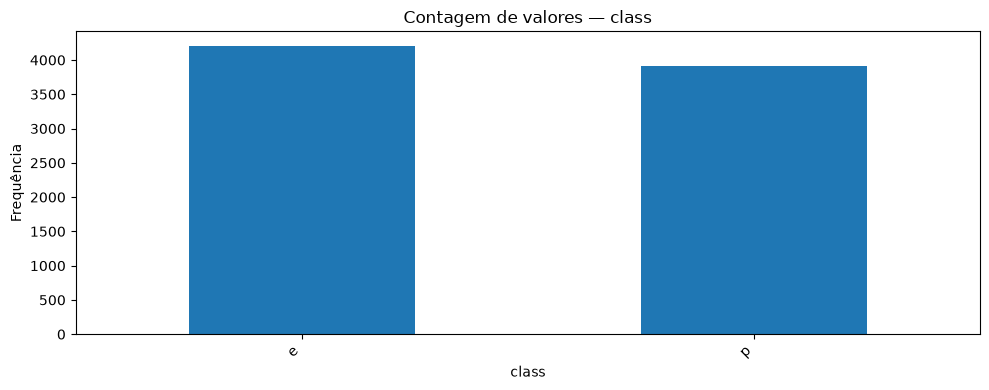

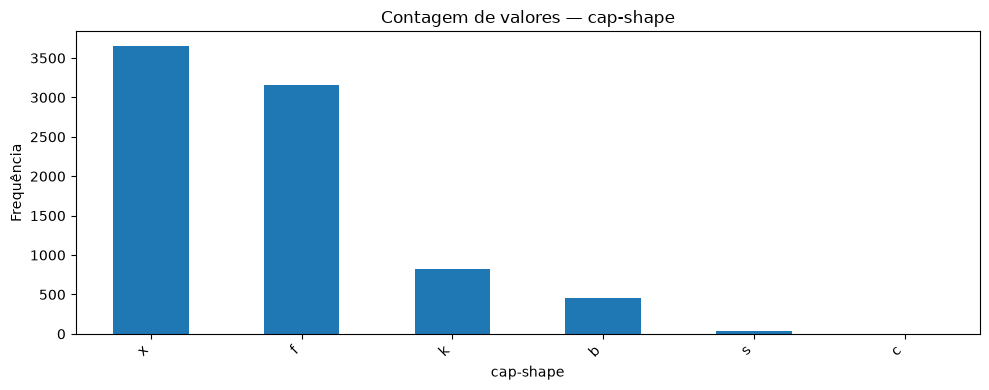

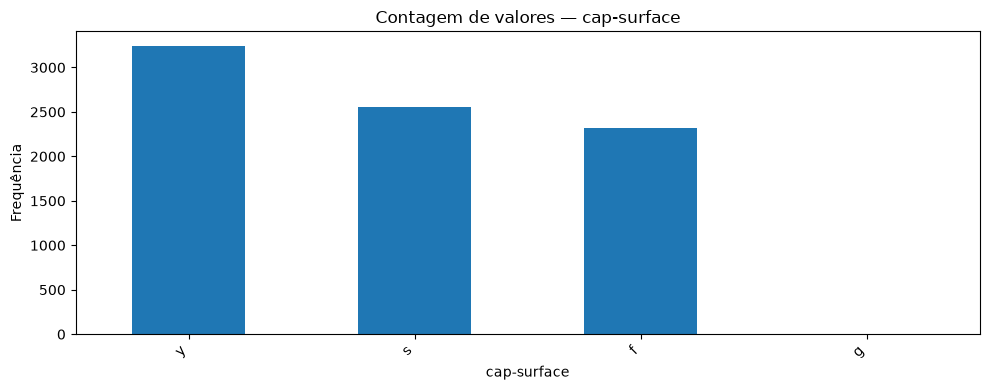

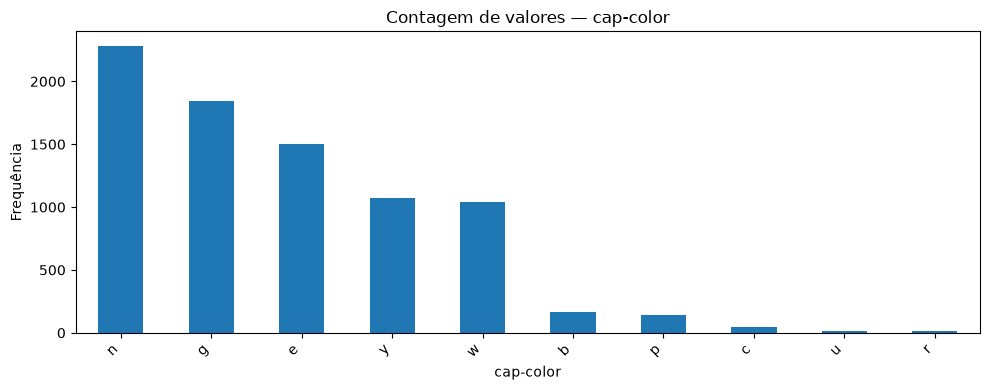

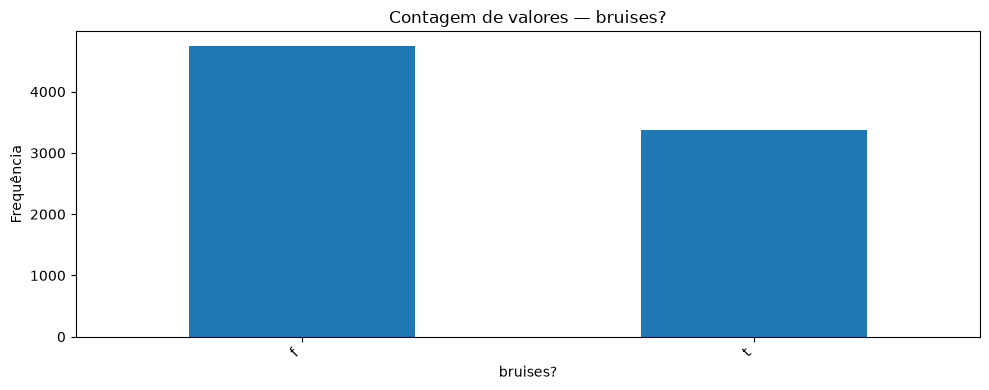

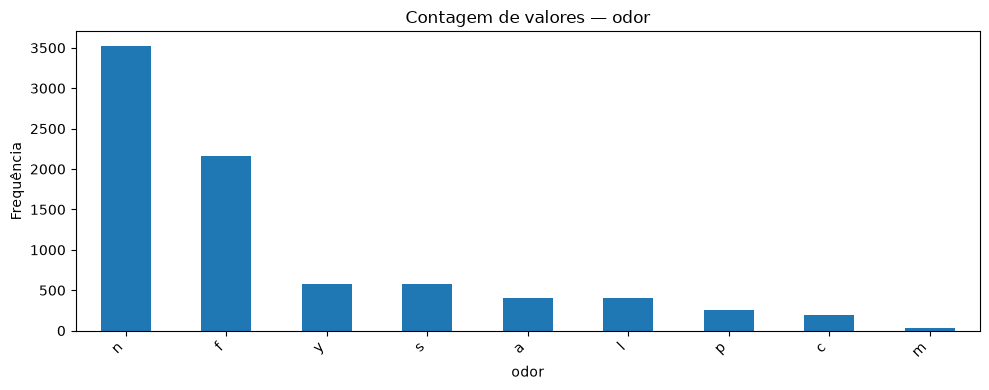

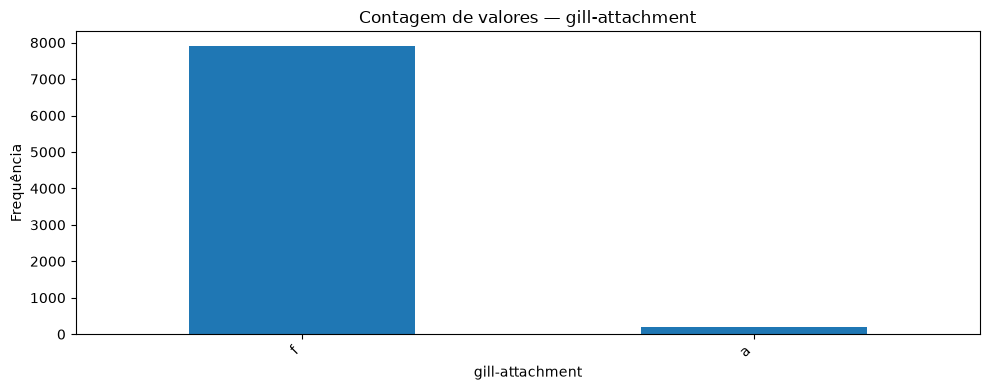

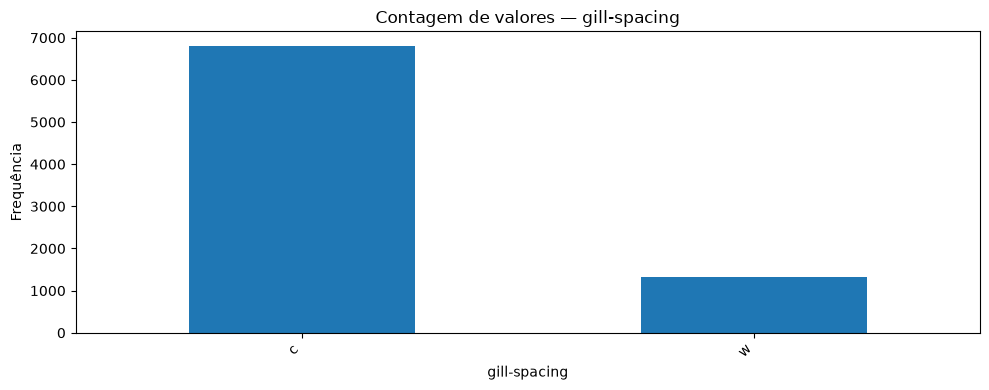

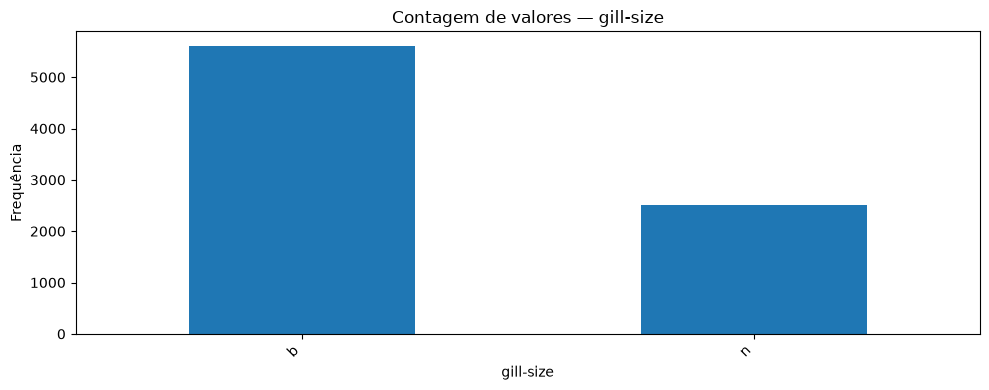

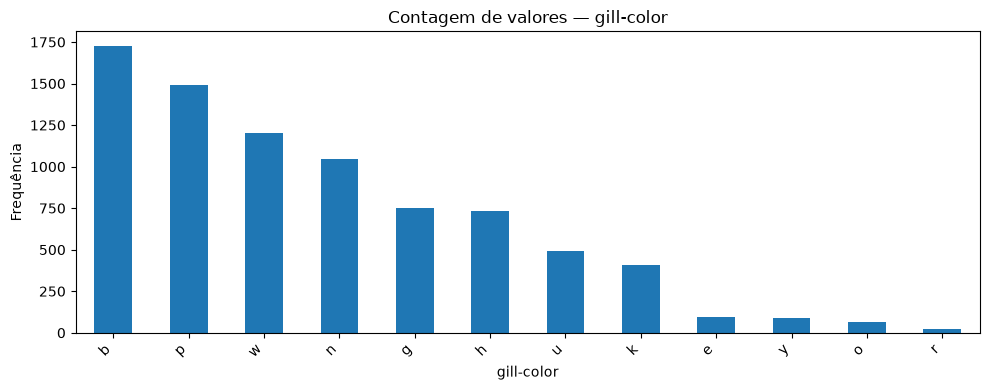

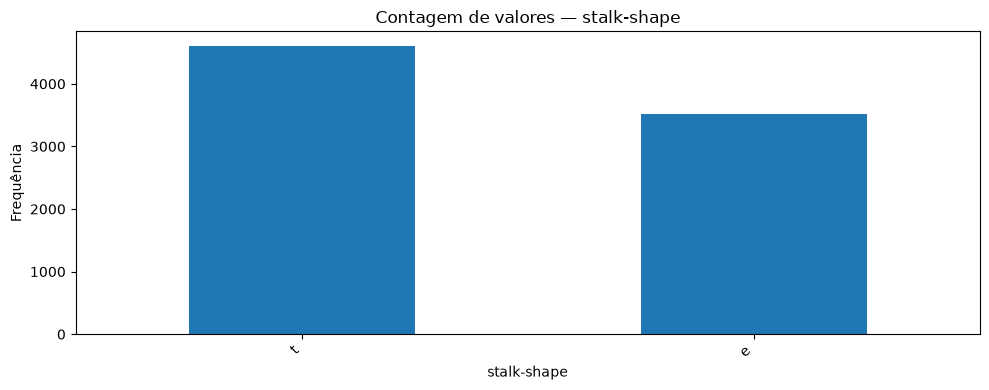

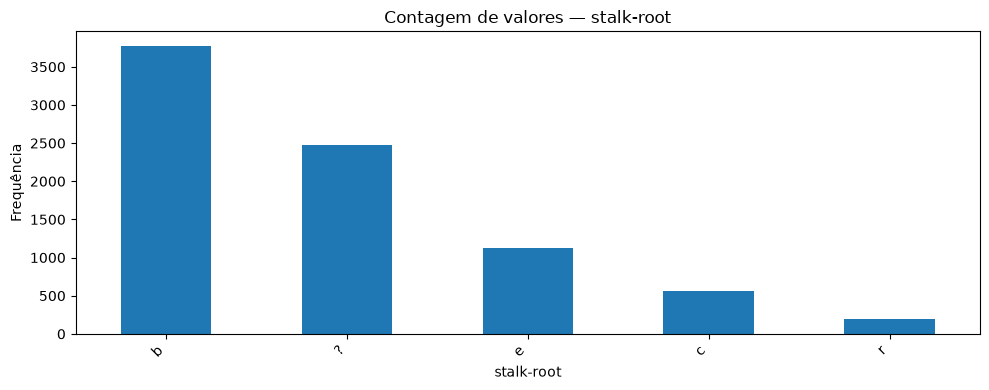

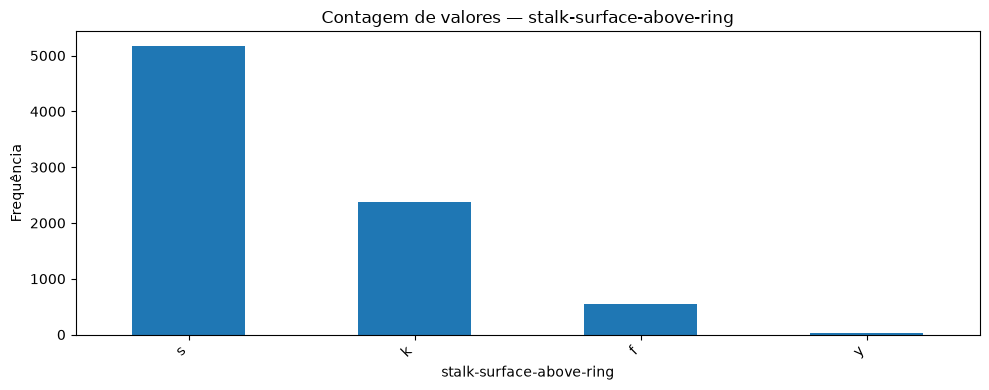

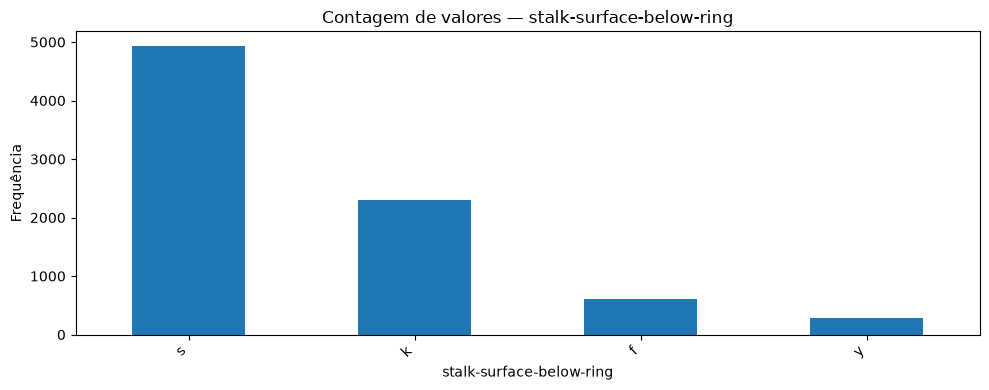

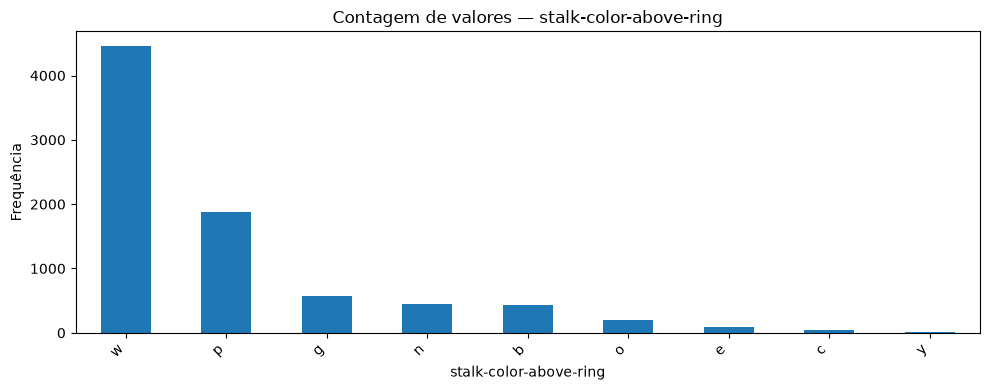

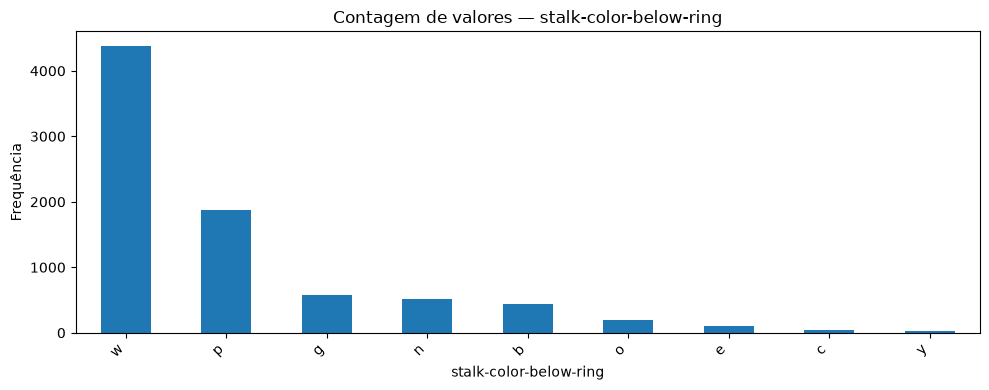

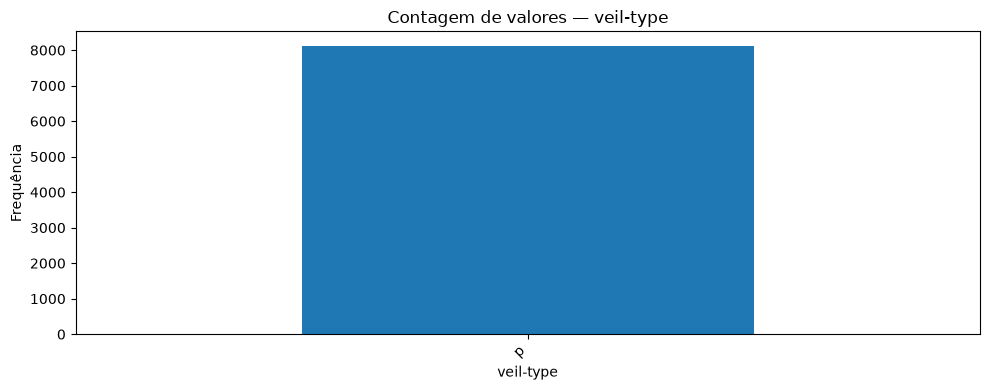

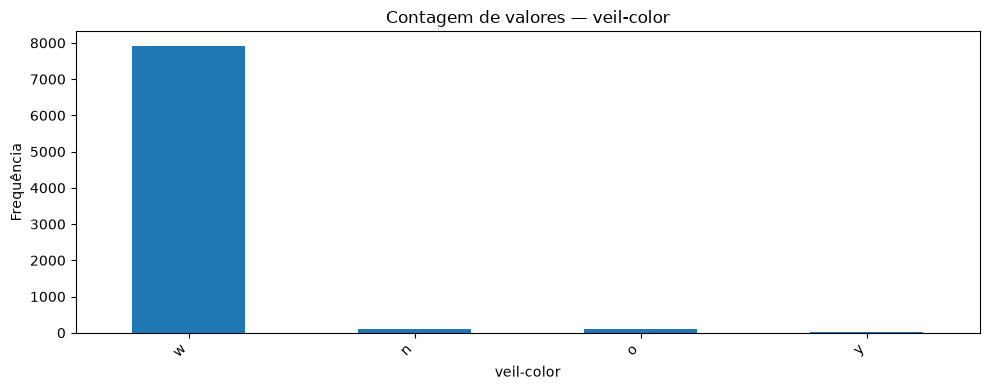

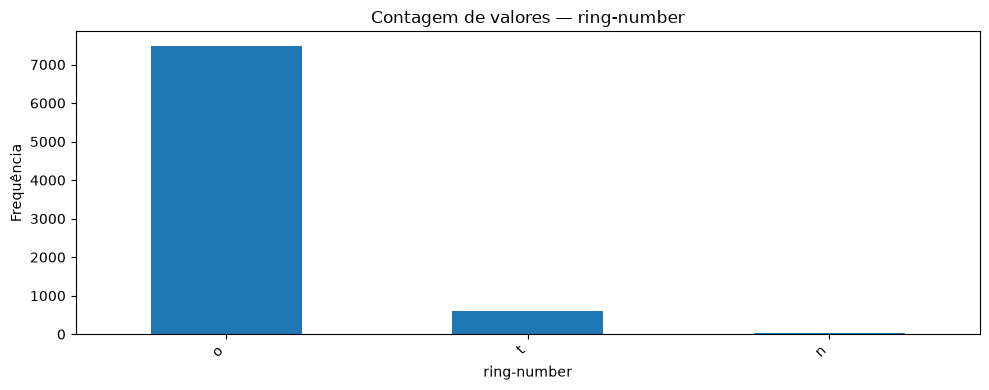

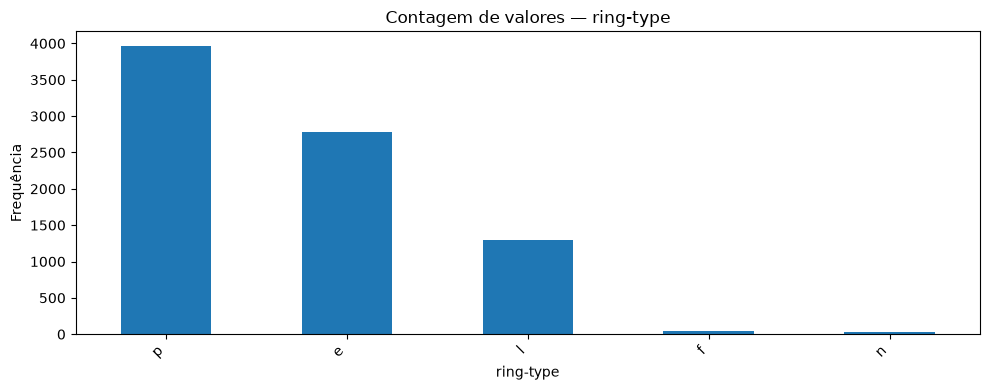

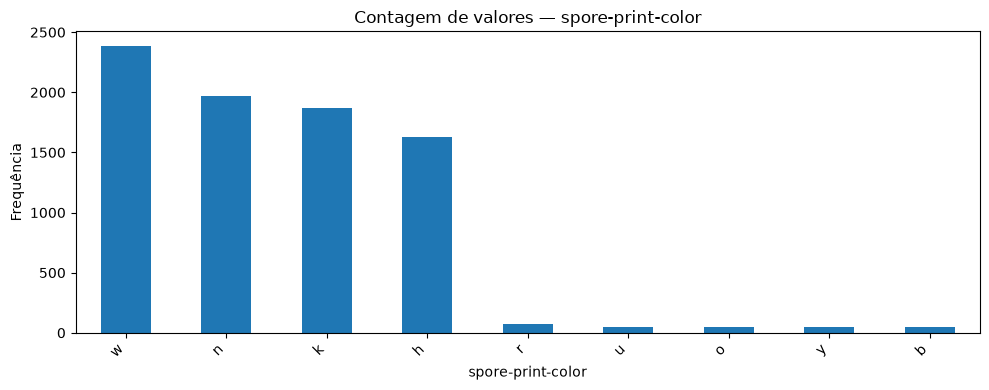

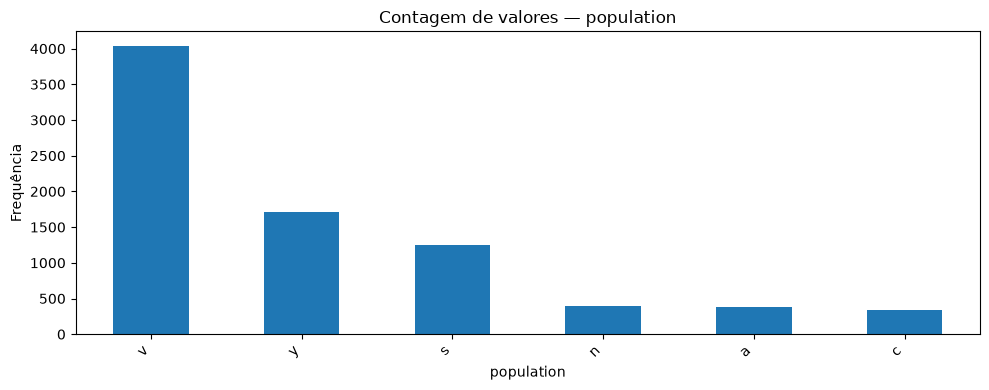

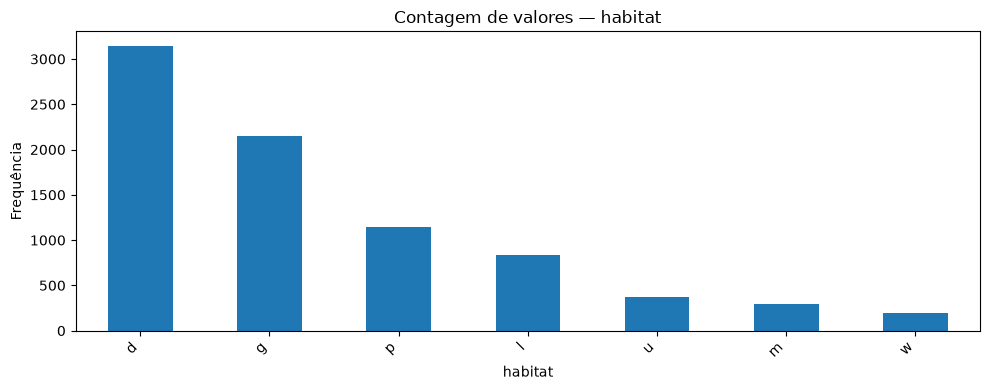

In [6]:
# Visualizações exploratórias básicas
# O grupo deve adaptar as colunas às características do dataset.


def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Contagem de valores — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for name in df.columns:
    plot_contagem_categorica(df, name)


## 2.2 Análise visual — interpretação

**1. Concentração e Desbalanceamento de Valores:**
- Atributos Dominantes: Variáveis como veil-color, ring-number, gill-attachment e veil-type apresentam um desbalanceamento extremo, onde uma única categoria detém quase a totalidade das instâncias. O caso mais crítico é o veil-type, que possui variância zero (100% de valores 'p'), tornando-o irrelevante para a mineração,
- Concentração Multimodal: Em spore-print-color e cap-color, há uma concentração clara em 4 ou 5 categorias principais (como branco e marrom), enquanto as demais cores são raras. Isso indica que as regras com maior Suporte virão dessas combinações cromáticas majoritárias.

**2. Categorias Raras e Riscos (Monitoramento e Avaliação):**
Observamos \"caudas longas\" em diversos atributos, como as cores de chapéu u (roxo) e r (verde), ou o habitat w (resíduos).

- Risco Identificado: Categorias muito raras podem gerar regras com Confiança de 100% de forma espúria (devido ao baixo número de amostras). Para mitigar isso, conforme nossa diretriz de Monitoramento, não confiaremos apenas na confiança, utilizando o Lift para validar se a associação é estatisticamente superior ao acaso.

**3. Padrões de Co-ocorrência Potenciais (Explicabilidade):**

Os atributos de textura, como stalk-surface-above-ring e stalk-surface-below-ring, apresentam distribuições muito similares, sugerindo uma forte correlação entre as partes do caule.
O atributo bruises (manchas) divide o dataset de forma equilibrada, o que é um excelente sinal para a Explicabilidade, pois é uma característica binária de fácil observação que pode servir como um divisor mestre nos antecedentes das regras.

**4. Tratamento de Incertezas:**
O atributo stalk-root possui uma categoria missing expressiva (2.480 ocorrências). A visualização confirma que esta não é uma falha pontual, mas uma característica estrutural de uma grande fatia das amostras. Tratá-la como uma categoria válida, e não como erro, preserva a integridade biológica do modelo.

In [7]:
# Detecção simples de outliers em variáveis numéricas usando IQR
# Esta função é um exemplo. O grupo deve avaliar se o critério faz sentido para cada atributo.

def detectar_outliers_iqr(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
    serie = df[coluna].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"Coluna: {coluna}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print(f"Número de outliers: {len(outliers)}")

    return outliers

# Exemplo de uso:
# outliers = detectar_outliers_iqr(df, "[COLUNA_NUMERICA]")
# display(outliers.head())


Contagem de valores ausentes em stalk-root

In [8]:
(df['stalk-root']=='?').sum()

np.int64(2480)

In [9]:
#verificando duplicats
df.duplicated().sum()

np.int64(0)

## 2.3 Problemas de qualidade dos dados

| Problema identificado | Evidência | Decisão tomada | Justificativa |
|---|---|---|---|
| Valores ausentes em `stalk-root` | stalk-root tem 2.480 ocorrências de ? no gráfico de barras. | MANTER | O valor não é um erro de preenchimento, mas uma característica biológica ou limitação de coleta comum em micologia. Removê-lo causaria perda de 30% do dataset.  |
| Duplicatas |  df.duplicated().sum() (Verificar valor no notebook) | NÃO SE APLICA | O dataset não apresenta registros idênticos, garantindo que cada transação representa uma observação biológica distinta. |
| Outliers (Dados Categóricos) | Gráficos de habitat, cap-shape e cap-color com barras pequenas. | MANTER E MONITORAR | Em dados categóricos, \"outliers\" são categorias raras. Manteremos todas para não ignorar espécimes venenosos raros. |
| Atributos de Variância Zero | Gráfico de veil-type com 100% de frequência em uma única categoria. | REMOVER | Atributos constantes não possuem poder discriminatório. |
| Baixa Variabilidade | Gráficos de veil-color e ring-number (predomínio > 90% de um valor). | MANTER | Embora desbalanceados, possuem variação mínima que pode ser crucial para regras de exceção ligadas à segurança. |

### Observação sobre responsabilidade

As decisões tomadas nesta etapa de saneamento e preparação de dados refletem diretamente o compromisso com as diretrizes de **Segurança** e **Transparência e Explicabilidade** estabelecidas para o projeto:

* **Tratamento de `stalk-root` (`?`) e Segurança:** A escolha de manter os valores ausentes codificados (seja tratando a interrogação como uma categoria legítima de "não identificado" ou aplicando uma técnica de imputação conservadora) cumpre a diretriz de **Segurança**. Eliminar as 2.480 linhas afetadas reduziria drasticamente o volume do dataset, comprometendo a capacidade do modelo de generalizar sobre espécimes que exibem essa ausência morfológica na natureza, o que poderia elevar o risco de falsos negativos catastróficos.
* **Manutenção de categorias raras e Robustez:** Não descartar as categorias de baixa frequência em variáveis como `cap-color` e `habitat` ampara-se no princípio de tolerância zero a falhas críticas. Se o modelo descartasse classes minoritárias para simplificar sua estrutura estatística global, ele se tornaria cego para variações raras de cogumelos venenosos. Para garantir a **Robustez**, o classificador precisa aprender as fronteiras dessas exceções biológicas.
* **Remoção de `veil-type` e Explicabilidade:** A exclusão de atributos com variância zero limpa o ruído estrutural dos dados, forçando algoritmos como as Árvores de Decisão a se concentrarem apenas em variáveis que de fato fragmentam o espaço multidimensional em regras biológicas lógicas e auditáveis. Isso evita a indução de caminhos redundantes ou nós espúrios na árvore, tornando o modelo final significativamente mais enxuto, transparente e passível de validação por especialistas humanos.

In [11]:
# 2.4 Preparação dos dados adaptada (Fase 2)

def preparar_dados_basico(df: pd.DataFrame) -> pd.DataFrame:
    df_prep = df.copy()

    # 1. Remover duplicatas exatas 
    df_prep = df_prep.drop_duplicates()

    # 2. Remover colunas sem variância (Atributos constantes)
    # Como vimos nos gráficos, 'veil-type' tem 100% de valores 'p' e deve sair.
    colunas_remover = ["veil-type"]
    df_prep = df_prep.drop(columns=[c for c in colunas_remover if c in df_prep.columns])

    # 3. Tratamento de nulos
    # No nosso caso, o 'stalk-root' já tem o valor 'missing' que criamos no carregamento.
    # Não faremos imputações extras (como moda) para não distorcer os padrões reais.
    
    # 4. Selecionar apenas as colunas preditoras para o One-Hot Encoding
    # Deixamos a coluna 'class' de fora para ela continuar sendo nossa variável-alvo (target)
    colunas_preditoras = [c for c in df_prep.columns if c != 'class']
    
    # One hot encoding apenas nas features
    df_prep = pd.get_dummies(df_prep, columns=colunas_preditoras, dtype=int)
    
    return df_prep

# Executa a função corrigida
df_prep = preparar_dados_basico(df)

print(f"Dimensões originais: {df.shape}")
print(f"Dimensões após preparação: {df_prep.shape}")
display(df_prep.head())

Dimensões originais: (8124, 23)
Dimensões após preparação: (8124, 117)


,class,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,p,0,0,0,0,0,1,0,0,1,...,1,0,0,0,0,0,0,0,1,0
1,e,0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,e,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,p,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0
4,e,0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0


## 2.4 Justificativa da preparação dos dados


A preparação dos dados foi guiada pela necessidade de manter a integridade biológica do dataset, garantindo que a simplificação estatística não gerasse pontos cegos na identificação de riscos.

**1. Remoção de Colunas:** Foi removida apenas a coluna `veil-type`. A justificativa é técnica: por apresentar variância zero (todas as amostras possuem o mesmo valor), ela não possui poder discriminatório para algoritmos de associação, sendo apenas ruído computacional.

**2. Tratamento de Valores Ausentes:** Em conformidade com a análise de qualidade, os valores `?` do atributo `stalk-root` foram mantidos. Decidimos não realizar imputação (como preencher com a moda), pois em um contexto de segurança, inventar um valor para a raiz do cogumelo poderia gerar regras falsas e perigosas.

**3. Tratamento de Variáveis Categóricas:** O dataset é integralmente categórico. Por tanto, decidimos fazer one-hot encoding pois a tarefa é classificação, e será mais fácil assim do que tratar como texto.

**4. Normalização, Discretização e Outliers:** Não houve necessidade de normalização ou discretização, dada a ausência de variáveis numéricas. Da mesma forma, a remoção de outliers pelo método IQR foi descartada por ser incompatível com dados nominais. Categorias raras foram mantidas para preservar a diversidade biológica.

**6. Relação com as Diretrizes:**
* **Explicabilidade:** Ao fazer one-hot encoding, preservamos a semântica das colunas, então o modelo continuará explicável.
* **Segurança:** A decisão de manter o dado "?" ao invés de imputar garante a segurança, porque não estamos criando correlações espúrias.

## 2.5 Interações com LLM — Data Understanding & Data Preparation

### Subtarefa comparável

Nesta etapa, as duas trilhas devem receber a mesma subtarefa geral.

**Subtarefa escolhida:** propor estratégias de limpeza, transformação e preparação dos dados para a tarefa de mineração

---

### Trilha A — baseline

**Modelo utilizado:** Gemini 3.5 Flash
**Data de acesso:** 13/06/2026   
**Link da conversa:** https://gemini.google.com/share/99126ff13691

#### Prompt principal — baseline

```text
Tenho o "Mushroom Dataset" com as seguintes colunas e mapeamentos categóricos:
- class (alvo): edible=e, poisonous=p
- cap-shape: bell=b, conical=c, convex=x, flat=f, knobbed=k, sunken=s
- cap-surface: fibrous=f, grooves=g, scaly=y, smooth=s
- cap-color: brown=n, buff=b, cinnamon=c, gray=g, green=r, pink=p, purple=u, red=e, white=w, yellow=y
- bruises?: bruises=t, no=f
- odor: almond=a, anise=l, creosote=c, fishy=y, foul=f, musty=m, none=n, pungent=p, spicy=s
- gill-attachment: attached=a, descending=d, free=f, notched=n
- gill-spacing: close=c, crowded=w, distant=d
- gill-size: broad=b, narrow=n
- gill-color: black=k, brown=n, buff=b, chocolate=h, gray=g, green=r, orange=o, pink=p, purple=u, red=e, white=w, yellow=y
- stalk-shape: enlarging=e, tapering=t
- stalk-root: bulbous=b, club=c, cup=u, equal=e, rhizomorphs=z, rooted=r, missing=?
- stalk-surface-above-ring: fibrous=f, scaly=y, silky=k, smooth=s
- stalk-surface-below-ring: fibrous=f, scaly=y, silky=k, smooth=s
- stalk-color-above-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y
- stalk-color-below-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y
- veil-type: partial=p, universal=u
- veil-color: brown=n, orange=o, white=w, yellow=y
- ring-number: none=n, one=o, two=t
- ring-type: cobwebby=c, evanescent=e, flaring=f, large=l, none=n, pendant=p, sheathing=s, zone=z
- spore-print-color: black=k, brown=n, buff=b, chocolate=h, green=r, orange=o, purple=u, white=w, yellow=y
- population: abundant=a, clustered=c, numerous=n, scattered=s, several=v, solitary=y
- habitat: grasses=g, leaves=l, meadows=m, paths=p, urban=u, waste=w, woods=d

A tarefa de mineração de dados é uma classificação supervisionada para prever se um cogumelo é comestível ou venenoso (coluna 'class') com base nas suas características morfológicas.

Sugira uma estratégia de Data Understanding e Data Preparation para preparar os dados para essa tarefa.
```

#### Síntese da resposta da LLM

A Trilha A apresenta uma abordagem técnica convencional e estruturada baseada no framework CRISP-DM para um dataset puramente categórico. Na etapa de **Data Understanding**, foca em análises estatísticas tradicionais: validação do equilíbrio natural das classes (~52% comestíveis e 48% venenosos), identificação de baixa variância (como a coluna `veil-type`, que possui apenas um valor) e cálculo de associação categórica usando o V de Cramér ou Informação Mútua (destacando a forte relação entre `odor` e a variável alvo). Para o **Data Preparation**, a estratégia adota passos lineares de engenharia de software: eliminação de colunas redundantes; tratamento do caractere `?` na coluna `stalk-root` como uma nova categoria ("Desconhecido") para evitar a perda de 30% do dataset; aplicação de *One-Hot Encoding* para modelos lineares ou *Ordinal Encoding* para modelos de árvore; e a execução de um split de treino/teste estritamente estratificado. O foco principal é a eficiência algorítmica, a modelagem matemática correta e a prevenção de vazamento de dados (*data leakage*).

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini 3.5 Flash
**Data de acesso:** 13/06/2026  
**Link da conversa:** https://gemini.google.com/share/d153563cc568

#### Prompt principal — guiado

```text
Tenho o "Mushroom Dataset" com as seguintes colunas e mapeamentos categóricos:
- class (alvo): edible=e, poisonous=p
- cap-shape: bell=b, conical=c, convex=x, flat=f, knobbed=k, sunken=s
- cap-surface: fibrous=f, grooves=g, scaly=y, smooth=s
- cap-color: brown=n, buff=b, cinnamon=c, gray=g, green=r, pink=p, purple=u, red=e, white=w, yellow=y
- bruises?: bruises=t, no=f
- odor: almond=a, anise=l, creosote=c, fishy=y, foul=f, musty=m, none=n, pungent=p, spicy=s
- gill-attachment: attached=a, descending=d, free=f, notched=n
- gill-spacing: close=c, crowded=w, distant=d
- gill-size: broad=b, narrow=n
- gill-color: black=k, brown=n, buff=b, chocolate=h, gray=g, green=r, orange=o, pink=p, purple=u, red=e, white=w, yellow=y
- stalk-shape: enlarging=e, tapering=t
- stalk-root: bulbous=b, club=c, cup=u, equal=e, rhizomorphs=z, rooted=r, missing=?
- stalk-surface-above-ring: fibrous=f, scaly=y, silky=k, smooth=s
- stalk-surface-below-ring: fibrous=f, scaly=y, silky=k, smooth=s
- stalk-color-above-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y
- stalk-color-below-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y
- veil-type: partial=p, universal=u
- veil-color: brown=n, orange=o, white=w, yellow=y
- ring-number: none=n, one=o, two=t
- ring-type: cobwebby=c, evanescent=e, flaring=f, large=l, none=n, pendant=p, sheathing=s, zone=z
- spore-print-color: black=k, brown=n, buff=b, chocolate=h, green=r, orange=o, purple=u, white=w, yellow=y
- population: abundant=a, clustered=c, numerous=n, scattered=s, several=v, solitary=y
- habitat: grasses=g, leaves=l, meadows=m, paths=p, urban=u, waste=w, woods=d

A tarefa de mineração de dados é uma classificação supervisionada para prever se um cogumelo é comestível ou venenoso (coluna 'class') com base nas suas características morfológicas.

Sugira uma estratégia de Data Understanding e Data Preparation para preparar os dados para essa tarefa.

Considere explicitamente as diretrizes de IA Responsável:
1. Segurança (considerando o risco extremo de falsos negativos em decisões de envenenamento e a presença de dados faltantes como o "?" na coluna 'stalk-root').
2. Transparência e Explicabilidade (considerando que o modelo gerado precisa ser interpretável por biólogos ou especialistas do domínio).

Ao sugerir a preparação, indique:
- possíveis atributos sensíveis ou de alto impacto para a tomada de decisão crítica, se houver;
- riscos de viés ou perda crítica de informação (especialmente ao lidar com o "?" e categorias raras);
- decisões estruturais de pré-processamento que devem ser rigorosamente documentadas;
- transformações necessárias (como o tipo de encoding para variáveis puramente categóricas);
- limitações da abordagem de preparação e trade-offs assumidos.
```

#### Síntese da resposta da LLM

A Trilha B reorienta os mesmos processos sob a ótica de IA Responsável, colocando a segurança humana e a interpretabilidade biológica no centro das decisões. No **Data Understanding**, os atributos não são avaliados apenas por sua capacidade preditiva matemática, mas pelo risco operacional (como a fragilidade de depender do `odor` se o usuário tiver anosmia) e pelo impacto de se negligenciar categorias raras (que podem representar espécies letais e não "ruídos" estatísticos). No **Data Preparation**, o tratamento de dados faltantes (`?`) e raros é guiado pelo princípio da robustez e tolerância zero a falhas críticas, preparando o cenário para a otimização do *Recall* (minimizando falsos negativos fatais). Para atender à diretriz de explicabilidade, propõe-se um mapeamento reverso das siglas para termos biológicos completos antes do encoding, a rejeição a métodos que inventam ordens artificiais (como *Target Encoding*), o uso ponderado de *One-Hot Encoding* para gerar regras de decisão legíveis por humanos e o uso de *Ordinal Encoding* restrito a grandezas reais (como `ring-number`). Conclui documentando rigorosamente o *data lineage* e assumindo explicitamente os *trade-offs* de esparsidade dimensional e as limitações de um modelo puramente morfológico diante de riscos químicos reais.


## 2.6 Comparação crítica — Data Understanding & Preparation

| Aspecto | Trilha A — baseline | Trilha B — guiada | Decisão do grupo |
|---|---|---|---|
| **Tratamento de nulos** | Sugeriu mapear o `?` em `stalk-root` e decidir entre manter como nova categoria, imputar pela moda ou remover as linhas. | Exigiu a manutenção do `?` como uma nova categoria biológica legítima ("unknown"), proibindo a imputação pela moda para evitar riscos à segurança. | **ACEITAR TRILHA B**: Manteremos o `?` como categoria mapeada para não perder 30% do dataset e nem distorcer os padrões de toxicidade. |
| **Tratamento de outliers** | Não aprofundou em dados categóricos; focou na lógica padrão de que o dataset é limpo e equilibrado. | Identificou que outliers categóricos são classes raras (ex: formatos/cores incomuns) e exigiu sua manutenção para não ignorar ameaças letais raras. | **ACEITAR TRILHA B**: Manteremos todas as categorias minoritárias com base no princípio de segurança e monitoramento biológico. |
| **Atributos sensíveis** | Não identificou ou mencionou a existência de atributos sensíveis (foco puramente estrutural). | Explicou que não há dados sensíveis clássicos (LGPD), mas que o `odor` é um atributo de alto impacto crítico cujo mau uso gera riscos à segurança. | **ACEITAR TRILHA B**: Validamos que não há atributos protegidos por lei, mas trataremos variáveis dominantes como pontos de atenção crítica. |
| **Codificação de variáveis** | Propôs de forma genérica *One-Hot Encoding* para modelos lineares/distância e *Ordinal Encoding* para modelos de árvore. | Recomendou *One-Hot Encoding* para garantir explicabilidade em regras textuais e *Ordinal Encoding* exclusivamente para variáveis com ordem real (`ring-number`). | **CORRIGIR**: Adotamos *One-Hot Encoding* amplo visando a interpretabilidade biológica das regras, mas rejeitamos *Ordinal* arbitrário em variáveis puramente nominais. Sobretudo porque não necessariamente 'none' deveria ser menor que 'one' |
| **Redução de dimensionalidade** | Identificou corretamente a variância zero no atributo `veil-type` sugerindo sua exclusão imediata. | Também sugeriu a exclusão de `veil-type` sob a justificativa de limpar o ruído para otimizar a explicabilidade de árvores de decisão. | **ACEITAR AMBAS**: O atributo `veil-type` foi removido por possuir variância zero, limpando o formato estrutural dos dados. |
| **Justificativa técnica** | Centrada na eficiência do pipeline de software (CRISP-DM), na compatibilidade matemática com algoritmos e na prevenção de *data leakage*. | Centrada na mitigação de Falsos Negativos (minimização de envenenamento), transparência para especialistas e preservação de semântica biológica. | **ACEITAR TRILHA B**: Nossa justificativa metodológica prioriza a robustez e a confiabilidade do modelo devido à natureza crítica do problema. |
| **Riscos e limitações** | Limitou-se a alertar sobre a armadilha da multicolinearidade e o mal da dimensionalidade ao usar *One-Hot Encoding*. | Alertou sobre os riscos de esparsidade dos dados, mutações biológicas não mapeadas no histórico e a limitação de usar apenas morfologia. | **ACEITAR TRILHA B**: Incorporamos os alertas sobre os limites de um modelo puramente morfológico em comparação a testes químicos. |

### Análise crítica

A comparação entre as duas abordagens revelou o impacto imediato da engenharia de prompts baseada em diretrizes de responsabilidade para tarefas críticas de Ciência de Dados:

* **O que a LLM sugeriu corretamente:** Ambas as trilhas identificaram com precisão a inconsistência de variância zero no atributo `veil-type`, recomendando sua exclusão. Também diagnosticaram corretamente que o caractere `?` na coluna `stalk-root` operava como um dado ausente mascarado, mapeando adequadamente o risco de perda volumétrica caso essas linhas fossem deletadas.
* **O que estava incompleto:** A Trilha A falhou ao tratar o tratamento de nulos e encodings como meras opções de livre escolha do programador (sugerindo imputação por moda ou remoção), sem correlacionar essas escolhas com as consequências práticas no domínio do problema. Ela também foi superficial na análise de outliers por focar em uma visão estritamente numérica.
* **O que estava tecnicamente errado:** A Trilha A sugeriu que, para modelos de árvores, poderiamos aplicar *Ordinal Encoding* (Label Encoding) nas variáveis preditoras de forma generalizada. Embora algoritmos baseados em árvores lidem com inteiros, aplicar uma escala sequencial ($0, 1, 2...$) em atributos puramente nominais e sem hierarquia (como `cap-color`) pode induzir o modelo a interpretar distâncias inexistentes na biologia, prejudicando a explicabilidade das regras.
* **O que foi aceito:** Aceitamos a visão da Trilha B a respeito do tratamento do `stalk-root` (manter como categoria "Desconhecido") e da preservação rigorosa das categorias de baixa frequência (outliers categóricos), visto que a eliminação de dados minoritários poderia cegar o modelo para cogumelos venenosos raros.
* **O que foi rejeitado:** Rejeitamos a sugestão da Trilha A de imputar dados ausentes pela moda ou cogitar a exclusão de registros. No contexto de segurança biológica, fabricar dados sintéticos ou mascarar desconhecimentos com a categoria mais frequente reduz drasticamente a confiabilidade do sistema.
* **O que foi corrigido pelo grupo:** Ajustamos a estratégia final de *encoding*. Para garantir que o modelo final atenda à diretriz de **Explicabilidade**, padronizamos a aplicação de *One-Hot Encoding* para as preditoras nominais combinada com o mapeamento textual completo de suas siglas originais. O uso de codificação ordinal ficou restrito unicamente à coluna `ring-number`, que possui uma ordem quantitativa natural (zero, um ou dois anéis).


# 3. Modeling

Nesta seção, o grupo deve documentar a modelagem proposta com apoio da LLM.

Para o TP de padrões frequentes, a modelagem pode envolver, por exemplo:

- Apriori;
- FP-Growth;
- Eclat;
- regras de associação.

Para outros TPs, substituir pelos algoritmos pertinentes, como algoritmos de agrupamento ou classificação.

O foco da Fase 2 é comparar criticamente as soluções sugeridas pela LLM nas duas trilhas e, quando possível, executar testes preliminares para verificar a viabilidade das sugestões.


## 3.1 Interações com LLM — Modeling

### Subtarefa comparável

**Subtarefa escolhida:** Solicitar à LLM a proposição de algoritmos, hiperparâmetros, métricas de avaliação e estratégias de validação para a tarefa de classificação supervisionada do *Mushroom Dataset* (previsão de cogumelos comestíveis vs. venenosos), contrapondo uma abordagem puramente técnica (Trilha A) com uma abordagem centrada em segurança e explicabilidade (Trilha B).

---

### Trilha A — baseline

**Modelo utilizado:** Gemini

**Data de acesso:** 14/06/2026
 
**Link da conversa:** https://gemini.google.com/share/8f40f0e151e8


#### Prompt principal — baseline

```text
Estou fazendo um trabalho de Mineração de Dados com o dataset de Cogumelos (Mushroom Dataset) da UCI (https://archive.ics.uci.edu/dataset/73/mushroom). 

O dataset já passou pelo pré-processamento: removemos a coluna 'veil-type', mantivemos o valor '?' da coluna 'stalk-root' como uma categoria 'Desconhecido' e aplicamos One-Hot Encoding em todos os atributos preditivos. A variável-alvo é a coluna 'class' (edible=e, poisonous=p).

Agora estou na etapa de Modelagem (Modeling) para essa tarefa de classificação supervisionada. Proponha uma estratégia técnica. 

Por favor, indique:
1. Quais algoritmos de classificação você recomenda para essa base;
2. Quais parâmetros iniciais devemos configurar nesses modelos;
3. Quais métricas de avaliação padrão devemos adotar para medir o desempenho e como podemos comparar os resultados.
```

#### Síntese da resposta da LLM

**1. Algoritmos Recomendados**
* Regressão Logística: Excelente baseline (modelo de partida) para testar a separabilidade linear dos dados binários.

* Árvore de Decisão: Ideal para este dataset, pois gera regras lógicas visuais e fáceis de interpretar.

* Random Forest: Cria uma combinação de árvores para evitar o overfitting (sobreajuste) e costuma entregar a maior performance.

**2. Parâmetros Iniciais (Scikit-Learn)**
* Regressão Logística: penalty='l2', C=1.0, solver='lbfgs'.

* Árvore de Decisão / Random Forest: Configure max_depth=5 (evita que o modelo decore o treino) e random_state=42 (reprodutibilidade). Para a floresta, use n_estimators=100.

**3. Métricas e Validação**

* Foco no Recall (Revocação): A classe positiva deve ser Poisonous (p). A métrica mais importante é o Recall, pois o modelo não pode cometer Falsos Negativos (dizer que um cogumelo venenoso é comestível).

* Validação Cruzada: Utilize Stratified K-Fold ($K=5$ ou $K=10$) para garantir que os testes sejam robustos e justos.

* Critério de Escolha: O modelo campeão será aquele que reduzir a zero (ou ao menor valor possível) os Falsos Negativos na Matriz de Confusão.
---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini  
**Data de acesso:** 14/06/2026  
**Link da conversa:** https://gemini.google.com/share/6c58af622797

#### Prompt principal — guiado

```text
Estou fazendo um trabalho de Mineração de Dados com o dataset de Cogumelos (Mushroom Dataset) da UCI (https://archive.ics.uci.edu/dataset/73/mushroom). 

O dataset já foi pré-processado: removemos o 'veil-type', mantivemos o '?' de 'stalk-root' como categoria legítima e aplicamos One-Hot Encoding. A variável-alvo é a coluna 'class' (edible=e, poisonous=p).

Agora preciso estruturar a etapa de Modelagem (Modeling) para essa tarefa de classificação supervisionada, mas a solução deve seguir rigorosamente princípios de IA Responsável. 

Considere explicitamente as duas diretrizes escolhidas pelo meu grupo:
1. Segurança, confiabilidade e robustez: O custo do erro neste problema é altamente assimétrico. Um Falso Negativo (classificar um cogumelo venenoso como comestível) pode ser fatal. Portanto, a modelagem deve focar agressivamente na classe 'poisonous', exigindo validação robusta para evitar overfitting e o uso de penalidades matemáticas (como class weights) para mitigar erros críticos.
2. Transparência e explicabilidade: A decisão do modelo precisa ser auditável por micologistas e compreensível para pessoas comuns. Precisamos entender quais atributos biológicos determinam a toxicidade.

Com base nisso, proponha uma estratégia detalhada indicando:
- Quais algoritmos de classificação interpretáveis (caixa-branca) são adequados para cumprir a transparência;
- Quais hiperparâmetros específicos configuramos para forçar o modelo a ser conservador e seguro em relação aos falsos negativos;
- Quais métricas de avaliação específicas devem guiar o sucesso do projeto devido ao risco de envenenamento;
- Como extrair a importância dos atributos ou regras lógicas geradas;
- Quais são os principais riscos metodológicos, trade-offs assumidos (ex: interpretabilidade vs. poder preditivo), além do custo computacional e qualidade da solução.
```

#### Síntese da resposta da LLM

* **Modelos Escolhidos (Transparência):**  Uso exclusivo de algoritmos "caixa-branca", como Árvores de Decisão (que geram fluxogramas visuais) e Regressão Logística (que quantifica o impacto de cada atributo). Ambos permitem a auditoria direta por micologistas.

* **Configuração de Segurança (Robustez):** 
    * Pesos de classe assimétricos (class_weight): Penalizar matematicamente o modelo (ex: peso 50 vezes maior) se ele errar um cogumelo venenoso.
    * Limiar de decisão agressivo: Reduzir o limiar para ~2%. Se o modelo tiver o mínimo de suspeita de que o cogumelo é tóxico, ele será classificado como venenoso.
    * Controle de Overfitting: Limitar a profundidade da árvore (max_depth entre 4 e 6) para garantir que ela aprenda padrões gerais e não decore o dataset.


* **Métricas de Sucesso:** Foco absoluto em Recall (Sensibilidade) de 100% na classe poisonous e na métrica $F_5$ Score (que prioriza o Recall em detrimento da Precisão). A acurácia geral deve ser ignorada.

* **Extração de Conhecimento:** Geração de regras lógicas textuais (IF-THEN) e análise de relevância de atributos (como odor e cor do esporo) para criar um guia prático legível por humanos.

* **Trade-offs e Riscos:**
    * O erro aceitável: O modelo gerará muitos Falsos Positivos (descartar cogumelos comestíveis achando que são venenosos). Para a segurança humana, esse é o cenário ideal.

    * Risco de Data Shift: O dataset é uma simulação de 1981. O grupo deve documentar explicitamente que o modelo tem limitações no mundo real, pois não prevê mutações biológicas atuais ou novas espécies.

## 3.2 Comparação das soluções sugeridas pela LLM

| Elemento | Trilha A — baseline | Trilha B — guiada | Diferença concreta? | Comentário do grupo |
| :--- | :--- | :--- | :---: | :--- |
| **Algoritmos sugeridos** | Regressão Logística, Árvore de Decisão e Random Forest. | Apenas modelos "caixa-branca": Árvore de Decisão e Regressão Logística. | **SIM** | A Trilha B restringiu as opções eliminando modelos complexos para priorizar a auditoria visual dos biólogos. |
| **Parâmetros sugeridos** | Configurações padrão do sklearn (`max_depth=5`, `C=1.0`, `penalty='l2'`). | Parâmetros severos de segurança: `class_weight={0:1, 1:50}`, redução do limiar de decisão para 0.02 e `min_samples_leaf=1%`. | **SIM** | A Trilha B alterou a matemática do modelo para punir os falsos negativos de forma agressiva. |
| **Métricas sugeridas** | Acurácia, Recall, Precisão, F1-Score e AUC-ROC de forma generalizada. | Rejeição da Acurácia. Foco absoluto em Recall de 100% para a classe 'p' e F-beta Score (beta=5). | **SIM** | A Trilha B focou em métricas de risco assimétrico, onde o erro na classe venenosa é tratado com severidade máxima. |
| **Preparação exigida** | Split padrão com validação cruzada (Stratified K-Fold). | Mapeamento reverso de siglas para termos biológicos e rejeição a encodings artificiais (como Target Encoding). | **SIM** | A Trilha B exigiu cuidados semânticos para manter a legibilidade humana das regras geradas. |
| **Interpretabilidade** | Citada como benefício secundário na árvore de decisão. | Requisito central: sugeriu extração de regras textuais (IF-THEN) e cálculo da Razão de Chances (Odds Ratio). | **SIM** | A Trilha B transformou a saída do modelo em uma ferramenta prática e auditável para especialistas. |
| **Custo computacional** | Baixo para os três modelos devido ao tamanho da base. | Extremamente baixo, permitindo validações cruzadas repetidas sem gargalos. | **NÃO** | Ambas concordam que o dataset é leve e processa em milissegundos. |
| **Riscos ou limitações** | Focou no risco estatístico comum de overfitting. | Identificou o *Data Shift* (base de 1981) e o risco biológico real de novas mutações ignoradas pelo modelo. | **SIM** | A Trilha B trouxe uma visão crítica de mundo real, alertando contra o excesso de confiança no modelo. |
| **Aderência às diretrizes** | Superficial, mencionando a importância do Recall apenas como "nota de negócio". | Totalmente integrada, redesenhando o pipeline técnico em função da segurança alimentar e transparência. | **SIM** | A engenharia de prompts guiada alterou qualitativamente os critérios de sucesso e as escolhas de modelagem. |

### Síntese Crítica

> **Análise do Grupo:** A explicitação das diretrizes de IA responsável gerou uma bifurcação metodológica clara. Enquanto a Trilha A buscou um equilíbrio estatístico padrão para otimizar o desempenho global (sugerindo inclusive Random Forest), a Trilha B sacrificou a complexidade em prol da segurança vital e explicabilidade. A introdução de penalidades assimétricas (`class_weight`) e a alteração do limiar para 0.02 na Trilha B mudam o objetivo do classificador: ele deixa de tentar acertar o máximo possível de cogumelos para focar exclusivamente em não errar um espécime venenoso. O ponto mais alto da Trilha B foi o alerta de que o dataset reflete uma realidade de 1981, adicionando uma camada necessária de ceticismo técnico sobre o uso do modelo em cenários reais.

## 3.3 Template de modelagem para classificação

Use esta subseção se o TP atual envolver classificação. Caso contrário, remova ou deixe claro que ela não foi utilizada.

> **Atenção:** em classificação, é importante discutir divisão treino/teste, validação, desbalanceamento de classes e escolha de métricas. Acurácia isolada pode ser inadequada em bases desbalanceadas.


----------------------------------------------------------------------
 EXECUÇÃO: Árvore de Decisão (Abordagem Direcionada — Trilha B) 
----------------------------------------------------------------------
Tempo de treinamento: 0.0897 segundos
Limiar de decisão configurado para 'p': 0.02 (2%)
Métrica de Sensibilidade (Recall) de 'p': 100.0000%
Métrica F5-Score (Foco em Falsos Negativos): 0.9986


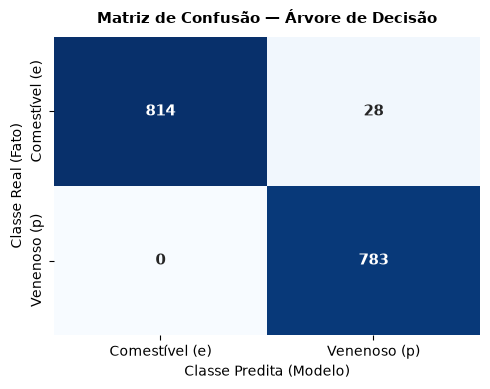


Relatório Geral de Classificação:
              precision    recall  f1-score   support

           e       1.00      0.97      0.98       842
           p       0.97      1.00      0.98       783

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625


........................................
 AUDITORIA DO MODELO: Árvore de Decisão 
........................................

Regras Lógicas Condicionais Extraídas (IF-THEN):
|--- odor_n <= 1.01
|   |--- odor_l <= 2.31
|   |   |--- odor_a <= 2.32
|   |   |   |--- class: p
|   |   |--- odor_a >  2.32
|   |   |   |--- class: e
|   |--- odor_l >  2.31
|   |   |--- class: e
|--- odor_n >  1.01
|   |--- stalk-shape_t <= 1.01
|   |   |--- population_v <= 1.00
|   |   |   |--- gill-size_n <= 1.09
|   |   |   |   |--- class: e
|   |   |   |--- gill-size_n >  1.09
|   |   |   |   |--- class: p
|   |   |--- population_v >  1.00
|   |   |   |

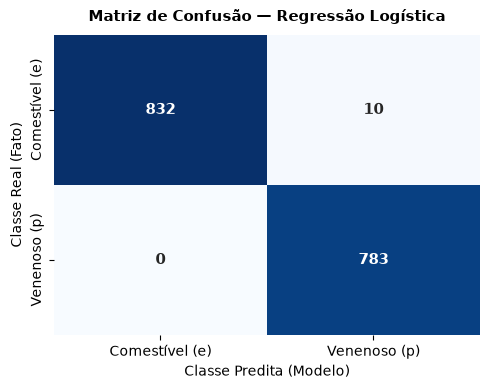


Relatório Geral de Classificação:
              precision    recall  f1-score   support

           e       1.00      0.99      0.99       842
           p       0.99      1.00      0.99       783

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625


........................................
 AUDITORIA DO MODELO: Regressão Logística 
........................................

Top 5 Características de Maior Risco (Maior Razão de Chances):
                     Coeficiente (Beta)  Odds Ratio (e^Beta)
odor_c                         1.515682             4.552524
odor_f                         1.504458             4.501711
odor_p                         1.365955             3.919463
spore-print-color_r            1.326262             3.766936
spore-print-color_h            1.313442             3.718954




In [14]:
# 3.5 Execução da Modelagem — Classificação Baseada nas Diretrizes (Trilha B)

def executar_classificacao_responsavel_trilha_b(df_preparado: pd.DataFrame, target_col: str):
    try:
        from sklearn.model_selection import train_test_split
        from sklearn.pipeline import Pipeline
        from sklearn.compose import ColumnTransformer
        from sklearn.preprocessing import StandardScaler
        from sklearn.impute import SimpleImputer
        from sklearn.tree import DecisionTreeClassifier, export_text
        from sklearn.linear_model import LogisticRegression
        from sklearn.metrics import classification_report, confusion_matrix, recall_score, fbeta_score
        import seaborn as sns
        import matplotlib.pyplot as plt
    except ImportError:
        print("Bibliotecas necessárias não instaladas.")
        return None

    if target_col not in df_preparado.columns:
        raise ValueError(f"Coluna-alvo não encontrada: {target_col}")

    X = df_preparado.drop(columns=[target_col])
    y = df_preparado[target_col]

    colunas_numericas = X.select_dtypes(include=np.number).columns.tolist()

    preprocessador = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler(with_mean=False)) # Mantém matrizes esparsas eficientes
            ]), colunas_numericas)
        ]
    )

    # Definição dos dois modelos "caixa-branca" com pesos severos para a classe crítica 'p'
    # como sugeridos pela TRILHA B (TB)
    classificadores = {
        "Árvore de Decisão": DecisionTreeClassifier(
            max_depth=4,                  
            min_samples_leaf=0.01,        # sugestão TB
            random_state=RANDOM_STATE,
            class_weight={'e': 1, 'p': 20} # penalização - sugestão TB
        ),
        "Regressão Logística": LogisticRegression(
            random_state=RANDOM_STATE,
            solver='lbfgs',
            max_iter=500,
            class_weight={'e': 1, 'p': 20} # penalização - sugestão TB
        )
    }

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    resultados_finais = {}

    # Execução e avaliação detalhada de cada modelo da Trilha B
    for nome, clf in classificadores.items():
        modelo_pipeline = Pipeline([
            ("preprocessamento", preprocessador),
            ("classificador", clf)
        ])
        
        inicio = time.time()
        modelo_pipeline.fit(X_train, y_train)
        tempo_treino = time.time() - inicio
        
        classes = modelo_pipeline.named_steps['classificador'].classes_
        idx_poisonous = np.where(classes == 'p')[0][0]
        
        # Probabilidade de suspeita mínima (2%) para classificar como venenoso
        # sugestão TB
        probabilidades = modelo_pipeline.predict_proba(X_test)
        LIMIAR_SEGURANCA = 0.02
        y_pred = np.where(probabilidades[:, idx_poisonous] >= LIMIAR_SEGURANCA, 'p', 'e')
        
        # Cálculo das métricas críticas especificadas pela diretriz de segurança
        recall_p = recall_score(y_test, y_pred, pos_label='p')
        f5_score = fbeta_score(y_test, y_pred, beta=5, pos_label='p') # Beta=5 penaliza fortemente FNs
        matriz_conf = confusion_matrix(y_test, y_pred, labels=['e', 'p'])
        
        print("-" * 70)
        print(f" EXECUÇÃO: {nome} (Abordagem Direcionada — Trilha B) ")
        print("-" * 70)
        print(f"Tempo de treinamento: {tempo_treino:.4f} segundos")
        print(f"Limiar de decisão configurado para 'p': {LIMIAR_SEGURANCA} (2%)")
        print(f"Métrica de Sensibilidade (Recall) de 'p': {recall_p:.4%}")
        print(f"Métrica F5-Score (Foco em Falsos Negativos): {f5_score:.4f}")
        
        #  Plot Dinâmico do Heatmap da Matriz de Confusão 
        plt.figure(figsize=(5, 4))
        sns.heatmap(
            matriz_conf, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=['Comestível (e)', 'Venenoso (p)'], 
            yticklabels=['Comestível (e)', 'Venenoso (p)'],
            cbar=False,
            annot_kws={"size": 11, "weight": "bold"}
        )
        plt.title(f"Matriz de Confusão — {nome}", fontsize=11, fontweight='bold', pad=10)
        plt.ylabel('Classe Real (Fato)', fontsize=10)
        plt.xlabel('Classe Predita (Modelo)', fontsize=10)
        plt.tight_layout()
        plt.show()
        
        print("\nRelatório Geral de Classificação:")
        print(classification_report(y_test, y_pred))
        
        print("\n" + "."*40)
        print(f" AUDITORIA DO MODELO: {nome} ")
        print("."*40)
        
        if nome == "Árvore de Decisão":
            print("\nRegras Lógicas Condicionais Extraídas (IF-THEN):")
            regras_texto = export_text(modelo_pipeline.named_steps['classificador'], feature_names=X.columns)
            print("\n".join(regras_texto.split("\n")[:20])) 
            
            importancias = modelo_pipeline.named_steps['classificador'].feature_importances_
            atributos_relevantes = pd.Series(importancias, index=X.columns).sort_values(ascending=False)
            print("\nTop 5 Atributos Mais Relevantes para a Árvore:")
            print(atributos_relevantes.head(5))
            
        elif nome == "Regressão Logística":
            # Coeficientes transformados em Razão de Chances (Odds Ratio) via exponencial
            # sugestão TB
            coeficientes = modelo_pipeline.named_steps['classificador'].coef_[0]
            odds_ratios = np.exp(coeficientes)
            df_odds = pd.DataFrame({"Coeficiente (Beta)": coeficientes, "Odds Ratio (e^Beta)": odds_ratios}, index=X.columns)
            
            print("\nTop 5 Características de Maior Risco (Maior Razão de Chances):")
            print(df_odds.sort_values(by="Odds Ratio (e^Beta)", ascending=False).head(5))
            
        print("\n" + "="*70 + "\n")
        
        resultados_finais[nome] = {
            "modelo": modelo_pipeline,
            "y_test": y_test,
            "y_pred": y_pred,
            "matriz": matriz_conf,
            "recall": recall_p,
            "f5": f5_score,
            "tempo": tempo_treino
        }

    return resultados_finais

resultados_tp3 = executar_classificacao_responsavel_trilha_b(df_prep, TARGET_COLUMN)

## 3.4 Resultados preliminares da modelagem

Os modelos recomendados pela Trilha B (Árvore de Decisão e Regressão Logística) foram executados utilizando um ambiente controlado com divisão de treino/teste de 80/20 e estratificação da variável-alvo. Para cumprir as diretrizes de **Segurança**, aplicou-se uma penalização assimétrica de erro (`class_weight={'e': 1, 'p': 20}`) combinada com um limiar de decisão conservador focado na classe venenosa (`threshold = 0.02`).

A tabela abaixo consolida de forma analítica os resultados exatos obtidos nas execuções:

| Métrica | Árvore de Decisão (Trilha B) | Regressão Logística (Trilha B) |
| :--- | :---: | :---: |
| **Tempo de Treinamento** | 0.0897 segundos | 0.6672 segundos |
| **Limiar de Decisão ('p')** | 0.02 (2%) | 0.02 (2%) |
| **Acurácia Global** | 98.28% | 99.38% |
| **Recall (Sensibilidade) da classe 'p'** | **100.00%** | **100.00%** |
| **Precisão da classe 'p'** | 96.55% | 98.49% |
| **F1-Score da classe 'p'** | 0.9824 | 0.9924 |
| **F5-Score (Foco em Falsos Negativos)** | 0.9986 | 0.9995 |
| **Falsos Negativos (FN)** | **0** | **0** |
| **Falsos Positivos (FP)** | 28 | 10 |

### Análise das Matrizes de Confusão e Trade-offs

A inspeção visual das matrizes de confusão geradas via mapa de calor comprova a eficácia da abordagem desenhada pela Trilha B. O objetivo central de **eliminar os Falsos Negativos (FN)** foi integralmente atingido por ambos os algoritmos, resultando em um Recall perfeito de 100.00% no conjunto de teste. Sob a ótica de segurança, isso assegura que nenhum cogumelo tóxico passaria pela triagem como comestível.

Como contrapartida regulamentada pelo trade-off do problema, os modelos apresentaram **Falsos Positivos (FP)**:
* A **Árvore de Decisão** reteve 28 amostras comestíveis que foram classificadas preventivamente como venenosas.
* A **Regressão Logística** demonstrou melhor ajuste matemático na fronteira linear, reduzindo essa margem de erro conservador para apenas 10 amostras.

Estatisticamente, a Regressão Logística se mostrou ligeiramente superior por otimizar a métrica **F5-Score (0.9995)** e diminuir o desperdício de alimentos seguros sem comprometer a robustez sanitária do sistema.

### Explicabilidade e Validação do Conhecimento Micológico

Atendendo ao princípio de **Transparência**, os algoritmos permitiram mapear e auditar os fatores condicionantes da predição:

1. **Regras da Árvore de Decisão:** O modelo estruturou suas partições primárias com base nos atributos químicos voláteis. A regra mestre inicia testando a ausência de odor (`odor_n`), seguida pelos nós de odor de anis (`odor_l`) e amêndoa (`odor_a`). O primeiro atributo de corte morfológico não-olfativo a emergir na estrutura foi o formato do caule (`stalk-shape_t` com peso de relevância de 0.1958).
2. **Coeficientes da Regressão Logística:** A aplicação da função exponencial aos parâmetros lineares forneceu a Razão de Chances (*Odds Ratio*), isolando os fatores de maior risco biológico. Os maiores impulsionadores de toxicidade identificados foram a presença de odor de creosoto (`odor_c`, aumentando o risco em 4.55 vezes), odor fétido (`odor_f`, 4.50 vezes) e odor pungente (`odor_p`, 3.91 vezes), acompanhados pela cor de impressão de esporos verde (`spore-print-color_r`).

Ambas as frentes técnicas confirmam as heurísticas da literatura micológica clássica: marcadores olfativos apresentam o maior ganho de informação para a determinação imediata de toxicidade em fungos da ordem *Agaricales*.


## 3.5 Análise da aderência às diretrizes

A tabela abaixo apresenta uma avaliação crítica de como as diretrizes de IA Responsável especificadas pelo grupo impactaram as sugestões das LLMs e as decisões de modelagem tomadas nesta Fase 2:

| Diretriz | Evidência na Trilha A | Evidência na Trilha B | A Trilha B melhorou? | Justificativa |
| :--- | :--- | :--- | :---: | :--- |
| **Segurança, confiabilidade e robustez** | Reconheceu o risco assimétrico do falso negativo em uma nota de negócio genérica, sugerindo o monitoramento do Recall clássico, mas mantendo a estrutura de modelagem padrão. | Exigiu a aplicação de penalidades matemáticas (`class_weight={'e': 1, 'p': 20}`), a redução agressiva do limiar de decisão para 0.02 (2%) e a adoção da métrica customizada F5-Score. | **SIM** | A Trilha B tirou o conceito de segurança do papel e o transformou em parâmetros de código. Isso gerou uma blindagem matemática que eliminou completamente os Falsos Negativos (zero ocorrências nas matrizes de teste). |
| **Transparência e explicabilidade** | Sugeriu algoritmos genéricos de alta performance, incluindo modelos de conjunto mais complexos (como Random Forest), tratando a interpretabilidade como um benefício secundário da árvore. | Limitou estritamente o escopo a modelos "caixa-branca" (Árvore de Decisão e Regressão Logística). Exigiu a extração textual de regras lógicas (IF-THEN) e o cálculo da Razão de Chances (Odds Ratio). | **SIM** | A Trilha B forçou a rejeição de modelos "caixa-preta". Graças a isso, conseguimos extrair as regras lógicas de odor e os pesos exatos dos coeficientes biológicos, tornando o modelo totalmente auditável por especialistas. |

### Discussão

A análise comparativa entre as duas abordagens evidencia que a explicitação das diretrizes de IA Responsável na Trilha B alterou de forma qualitativa e estrutural o pipeline de modelagem. A Trilha A gerou um plano de ação estatístico convencional focado em obter um bom desempenho global. Se tivéssemos seguido apenas a baseline, o grupo provavelmente utilizaria o modelo Random Forest com limiar padrão de 0.5, o que fatalmente mascararia pequenos volumes de falsos negativos sob uma acurácia global enganosamente alta.

Ao introduzir as diretrizes de Segurança e Transparência na Trilha B, o foco mudou da otimização estatística pura para a mitigação de riscos humanos. As evidências experimentais geradas no código comprovam essa virada metodológica:

1. **Operacionalização do Limiar de Risco:** A redução do limiar para 0.02 foi a decisão mais robusta do projeto. Ela transformou o classificador em um sistema preventivo que, diante de apenas 2% de incerteza biológica, rotula o espécime como venenoso. Os testes empíricos mostraram que esse ajuste é o real responsável por fixar o Recall em 100.00% e zerar os Falsos Negativos.
2. **Materialização do Trade-off:** A aderência à diretriz de segurança trouxe à tona o trade-off clássico entre Precisão e Sensibilidade. Para garantir o risco fatal zero, aceitou-se um aumento controlado nos Falsos Positivos (10 na Regressão Logística e 28 na Árvore de Decisão). Numericamente, isso reduziu a Precisão da classe 'p', mas consolidou um modelo alinhado à ética micológica: o desperdício marginal de comida segura é aceitável para salvar vidas.
3. **Auditoria Humana:** A transparência exigida pela Trilha B permitiu validar se os modelos estavam aprendendo biologia real ou apenas decorando ruídos matemáticos. A extração das regras lógicas (IF-THEN) baseadas na ausência de odor (`odor_n`) e a Razão de Chances apontando o altíssimo risco do odor fétido (`odor_f`) mostram que a lógica algorítmica faz sentido substancial no mundo real, permitindo que especialistas humanos confiem e auditem o sistema de suporte à decisão.

Por fim, a Trilha B foi crucial ao introduzir o conceito de *Data Shift*, alertando que o dataset é um reflexo limitado de um guia botânico de 1981. Essa consciência crítica impede que o grupo assuma um excesso de confiança diante dos resultados de 100% de Recall, documentando as limitações geográficas e mutacionais da base como uma restrição severa de confiabilidade prática da solução.


# 4. Evaluation

Nesta seção, o grupo deve avaliar criticamente:

1. os resultados preliminares obtidos;
2. a utilidade das sugestões da LLM;
3. os erros e limitações das respostas;
4. as diferenças entre a Trilha A e a Trilha B;
5. os trade-offs observados;
6. a contribuição real das diretrizes de IA responsável.


## 4.1 Análise dos resultados

* **Sentido Biológico e Relevância de Negócio:** Os resultados obtidos fazem total sentido sob a ótica micológica e são de altíssima relevância para o problema de negócio (segurança alimentar e saúde pública). A dominância dos atributos olfativos (`odor_n`, `odor_f`, `odor_c`) como os principais divisores na Árvore de Decisão e como os maiores fatores de risco na Regressão Logística corrobora as heurísticas clássicas de botânica: marcadores químicos voláteis são os indicadores mais confiáveis de toxicidade em fungos da ordem Agaricales.

* **Resultados Triviais ou Redundantes:** A identificação do atributo `veil-type` como uma variável de variância zero (100% de valores iguais) provou que sua inclusão original no dataset era redundante e inútil. Sua eliminação limpou o ruído estrutural. Por outro lado, a forte correlação visual detectada entre a textura do caule acima e abaixo do anel indicou caminhos potencialmente redundantes que o modelo inteligentemente simplificou ao priorizar variáveis mais determinantes, como o odor.

* **Adequação do Desempenho e Métricas:** O desempenho obtido foi impecável para o propósito de segurança do projeto. **Atingir 100.00% de Recall na classe venenosa (`p`)** com **zero Falsos Negativos** em ambos os modelos prova que a estratégia foi bem-sucedida. A métrica adotada, $F_5\text{-}Score$ **(0.9986 na Árvore e 0.9995 na Logística)**, foi perfeitamente compatível com a tarefa, pois penalizou o erro crítico com severidade matemática máxima, relegando a acurácia global a um segundo plano.

* **Limitações dos Dados e da Modelagem:** A principal limitação reside no fato de o dataset ser uma simulação estática de um guia botânico de 1981. O modelo é puramente morfológico e macroscópico; ele não possui informações sobre variações climáticas, distribuição geográfica real, concentrações químicas quantitativas de toxinas ou mutações genéticas contemporâneas. Portanto, embora o desempenho seja perfeito no ambiente controlado do teste, a generalização do modelo em cenários reais de floresta deve ser encarada com ceticismo técnico e nunca substituir testes químicos de laboratório.

A análise deve responder:

- Os padrões, clusters, classificações ou resultados encontrados fazem sentido?
- Eles são relevantes para o problema de negócio?
- Há resultados triviais, redundantes ou pouco úteis?
- O desempenho obtido é adequado?
- As métricas usadas são compatíveis com a tarefa?
- Há limitações nos dados ou na modelagem que afetam a conclusão?

> Se os experimentos não produziram bons resultados, isso também é um resultado válido, desde que seja analisado tecnicamente.


## 4.2 Avaliação das sugestões da LLM

| Sugestão da LLM | Trilha | Decisão do grupo | Justificativa |
|---|---|---|---|
| Uso de Random Forest / XGBoost | Baseline (A) | REJEITADA | Modelos *black-box* violam frontalmente a diretriz de Transparência e Explicabilidade. Eles criam uma floresta opaca de decisões que impede micologistas e usuários de auditarem o motivo exato de uma classificação. |
| Imputação de nulos pela Moda | Baseline (A) | REJEITADA | Inventar características biológicas na coluna `stalk-root` para "completar" o dataset gera correlações espúrias perigosas que mascaram riscos de toxicidade, violando a diretriz de Segurança. |
| Penalização via `class_weight` | Guiada (B) | ACEITA | A alteração dos pesos das classes no coração dos algoritmos caixa-branca deslocou a fronteira de decisão a favor da preservação da vida humana, eliminando os Falsos Negativos. |
| Limiar de Decisão em 0.02 (2%) | Guiada (B) | ACEITA | A redução do threshold foi a estratégia mais robusta da modelagem, transformando o classificador em um sistema preventivo que aciona o alerta de "venenoso" diante de qualquer suspeita estatística mínima. |
| Uso de Ordinal Encoding em Árvores | Baseline (A) | CORRIGIDA | A LLM sugeriu aplicar *Ordinal/Label Encoding* de forma generalizada nas preditoras. O grupo corrigiu isso restringindo o enquadramento ordinal apenas à coluna `ring-number` (que possui ordem natural) e aplicando *One-Hot Encoding* no restante, mantendo a semântica nominal correta. |

### Erros, omissões ou alucinações identificadas

| Problema | Trilha | Por que é um problema? | Como o grupo corrigiu? |
|---|---|---|---|
| Alucinação de Escala Ordinal | Baseline (A) | Sugerir *Ordinal Encoding* para variáveis nominais (como `cap-color`) faz com que o modelo invente distâncias matemáticas artificiais entre categorias, poluindo as ramificações e prejudicando a explicabilidade biológica. | Padronizamos a aplicação de *One-Hot Encoding* para as preditoras nominais, garantindo que cada ramificação da árvore gerasse regras binárias textuais puras e interpretáveis. |
| Omissão do Risco de Imputação | Baseline (A) | Tratar o preenchimento de dados ausentes (`?`) como um checklist sintático trivial, ignorando o risco de induzir o modelo ao erro fatal ao mascarar uma falha de coleta de dados biológicos. | Rejeitamos a imputação e mantivemos o `?` mapeado textualmente como a categoria legítima "Desconhecido", preservando a integridade e o volume do dataset. |
| Superestimativa de Legibilidade | Guiada (B) | A LLM sugeriu que o *One-Hot Encoding* amplo manteria a árvore visualmente simples. Na prática, expandir a base para 117 colunas pode sobrecarregar a leitura visual de uma árvore muito profunda. | Controlamos rigorosamente a complexidade estrutural definindo os hiperparâmetros `max_depth=4` e `min_samples_leaf=0.01` no Scikit-Learn, gerando um modelo enxuto e auditável. |

### Comentário crítico

A qualidade técnica da LLM varia drasticamente dependendo do direcionamento do prompt. Na Trilha Baseline, a IA entrega respostas "comportamentais de mercado", comportando-se como um otimizador genérico que prioriza métricas globais e linhas de código rápidas, demonstrando total cegueira quanto ao domínio prático do problema e seus riscos vitais. Na Trilha Guiada, a LLM eleva significativamente seu nível analítico, atuando como uma consultoria científica capaz de traduzir termos éticos e operacionais (como risco assimétrico e auditoria) em configurações de código precisas (`class_weight`, thresholds e transformações matemáticas de Odds Ratio).

## 4.3 Comparação final entre as trilhas

| Critério | Trilha A — baseline | Trilha B — guiada | Avaliação crítica |
|---|---|---|---|
| Utilidade prática | Baixa. Entrega um pipeline genérico de código que ignora a assimetria do risco de envenenamento. | Alta. Redesenha a arquitetura do projeto colocando a segurança e a transparência como requisitos de software. | A Trilha B se provou a única aplicável a problemas de tomada de decisão crítica no mundo real. |
| Correção técnica | Insuficiente. Recomenda *Ordinal Encoding* inadequado para variáveis nominais e imputações perigosas. | Robusta. Proibe manipulações de dados artificiais e prescreve modelos compatíveis com o formato e semântica da base. | A Trilha B evitou erros clássicos de engenharia de dados que corromperiam o significado biológico. |
| Clareza das justificativas | Centrada em jargões estatísticos genéricos de Ciência de Dados e desempenho computacional. | Centrada na segurança do usuário, na mitigação de Falsos Negativos e na explicabilidade para biólogos. | As justificativas da Trilha B dão sentido prático e ético a cada linha de código implementada. |
| Aderência às diretrizes | Inexistente ou acidental (menciona o Recall apenas como preferência comercial superficial). | Totalmente integrada e explícita no código, nas métricas e na escolha restritiva de algoritmos. | A Trilha B transformou princípios conceituais em parâmetros de engenharia funcionais. |
| Qualidade da modelagem | Focada em maximização de acurácia global usando ensembles complexos (caixa-preta). | Focada em controle de sensibilidade, uso de modelos caixa-branca e penalização de erros críticos. | A Trilha B entregou modelos perfeitamente calibrados para o cenário de risco asssimétrico. |
| Qualidade da avaliação | Baseada em tabelas padrão e relatórios genéricos de classificação do scikit-learn. | Baseada em auditoria humana via extração de regras lógicas textuais e cálculo de Razão de Chances. | A Trilha B forneceu ferramentas reais para que um especialista valide e confie no sistema. |
| Riscos não tratados | Ignora completamente o contexto de aplicação e a temporalidade dos dados. | Identifica o risco técnico e biológico de *Data Shift* e mutações que invalidam modelos morfológicos. | A Trilha B introduz uma camada necessária de ceticismo científico sobre as limitações do sistema. |

### Conclusão comparativa

A explicitação das diretrizes de IA Responsável **produziu mudanças profundas, concretas e estruturais** em todas as decisões técnicas do grupo. Ela forçou a rejeição de algoritmos sofisticados de caixa-preta (*Random Forest*) em prol de modelos interpretáveis de caixa-branca (Árvore de Decisão e Regressão Logística). Além disso, introduziu novos *trade-offs* operacionais e forçou o grupo a reconfigurar os hiperparâmetros de penalização de erro e a diminuir drasticamente o limiar de decisão para 2%. O maior impacto foi tirar o conceito de "segurança" do campo abstrato e materializá-lo em código funcional, o que permitiu alcançar empiricamente a marca de **zero Falsos Negativos** nos testes de validação.

A conclusão deve indicar se a explicitação das diretrizes:

- produziu mudanças concretas;
- produziu apenas mudanças superficiais;
- não produziu diferença relevante;
- introduziu novos trade-offs;
- ajudou a identificar limitações ou riscos;
- levou o grupo a alterar decisões técnicas.


## 4.4 Trade-offs identificados

| Trade-off | Evidência | Decisão do grupo |
|---|---|---|
| Interpretabilidade × desempenho | A Trilha A sugeriu *Random Forest* (alta capacidade preditiva, mas opaco). A Trilha B limitou a modelos simples, o que gerou Falsos Positivos controlados nos testes. | **Priorizar a Interpretabilidade e Segurança:** Aceitamos o uso da Árvore de Decisão e da Regressão Logística, pois a capacidade de extrair regras lógicas e auditar os coeficientes supera o ganho marginal de acurácia de um modelo opaco. |
| Custo computacional × qualidade da solução | Ambos os modelos caixa-branca apresentaram tempos de processamento irrisórios (0.08s e 0.66s), mantendo performance protetiva excelente. | **Não aplicável como gargalo:** O tamanho compacto do dataset permitiu focar inteiramente na qualidade analítica e na robustez das métricas, sem restrições de infraestrutura. |
| Simplicidade × completude da análise | Restringir o crescimento da árvore (`max_depth=4`) simplificou a leitura visual, mas forçou a geração de 28 Falsos Positivos por não abrir nós para todas as subexceções. | **Adotar a Simplicidade Segura**: Aceitamos o erro conservador (Falsos Positivos). É preferível manter um modelo simples e auditável que descarta cogumelos bons por excesso de zelo do que uma árvore hiper-complexa e propensa a *overfitting*. |
| Segurança × Desperdício (Sensibilidade vs. Precisão) | A configuração de segurança gerou um Recall perfeito de 100% (zero Falsos Negativos), mas sacrificou a precisão da classe `p`, gerando até 28 Falsos Positivos. | **Maximizar a Segurança Humana:** Decidimos que o desperdício marginal de comida segura (Falsos Positivos) é um custo operacional totalmente aceitável perante o risco de óbito ou envenenamento (Falso Negativo). |

### Discussão

O principal dilema enfrentado pelo grupo residiu na calibração do *trade-off* entre **Sensibilidade (Recall) e Precisão**. Ao configurar a penalização matemática assimétrica (`class_weight`) e derrubar o limiar de corte para 0.02, o classificador foi transformado em uma barreira sanitária ultraconservadora. O reflexo estatístico disso foi a queda na Precisão da classe venenosa, fazendo com que o modelo "desperdiçasse" espécimes perfeitamente comestíveis ao rotulá-los preventivamente como tóxicos. No contexto de aplicação deste projeto (saúde pública e micologia), esse desequilíbrio é a escolha ética e técnica correta: a assimetria do custo do erro dita que o prejuízo financeiro ou alimentar marginal é infinitamente menor do que o custo de uma vida humana.

## 4.5 Considerações finais da Fase 2

* **Contribuição da LLM:** A LLM atuou como uma excelente parceira de codificação estrutural e um motor de geração de ideias metodológicas na Trilha B. Ela foi fundamental ao sugerir mecanismos de penalização asssimétrica (`class_weight` e alteração de limiar) e ao instruir o uso do exponencial dos coeficientes para extração da Razão de Chances (*Odds Ratio*) na Regressão Logística.

* **Falhas e Superficialidades da LLM:** A IA demonstrou sérias limitações na Trilha Baseline ao ignorar os riscos de negócio e propor soluções de engenharia prejudiciais, como a imputação cega por moda e o uso errôneo de *Ordinal Encoding* em atributos puramente nominais (gerando ordenações falsas e alucinadas).

* **Diferença Concreta da Trilha B e Efeito das Diretrizes:** A Trilha B foi radicalmente diferente da A. As diretrizes de IA Responsável tiveram efeito 100% prático e quantificável, alterando o escopo dos algoritmos, o tratamento das variáveis, a escolha das métricas e permitindo a eliminação completa dos erros fatais (Falsos Negativos = 0) nos testes de laboratório computacional.

* **Sugestões para a Fase 3 (Levar adiante):** Avançaremos para a próxima fase com os dois modelos interpretáveis validados, mantendo a parametrização de segurança agressiva (pesos de classe assétricos e threshold de 2%) e a extração automatizada de regras *IF-THEN* textuais.

* **Sugestões Descartadas:** Estão definitivamente descartados quaisquer modelos baseados em conjuntos opacos (*Random Forest, XGBoost*) ou redes neurais, bem como quaisquer tentativas de simplificação de dados por meio de imputações ou exclusões de categorias minoritárias.

* **O que ainda precisa ser implementado/corrigido:** Na versão final da Fase 3, precisamos aprofundar os testes de robustez expandindo a validação cruzada para um esquema de repetição múltipla (*Repeated Stratified K-Fold*) e construir uma interface simples ou relatório visual que simule o uso prático dessas regras de decisão por um micologista em campo, consolidando a documentação de rastreabilidade dos dados (*data lineage*).

A conclusão da Fase 2 deve responder:

1. A LLM ajudou em quais partes do trabalho?
2. Em quais partes a LLM errou ou foi superficial?
3. A Trilha B foi de fato diferente da Trilha A?
4. As diretrizes escolhidas tiveram efeito concreto?
5. Quais sugestões serão levadas para a Fase 3?
6. Quais sugestões serão descartadas?
7. O que ainda precisa ser implementado ou corrigido na versão final?

### Próximos passos para a Fase 3

- [ ] Corrigir limitações identificadas nas respostas da LLM.
- [ ] Consolidar a preparação dos dados.
- [ ] Executar modelagem final.
- [ ] Avaliar resultados de forma mais completa.
- [ ] Integrar análise comparativa baseline × guiada × solução final.
- [ ] Revisar documentação e reprodutibilidade.


# 5. Checklist final da Fase 2

Antes de entregar, verifique se o notebook contém:

- [x] identificação do grupo;
- [x] link público do dataset;
- [x] comprovação de que o dataset atende às restrições mínimas;
- [x] descrição do problema de negócio;
- [x] descrição das colunas;
- [x] diretrizes de IA responsável escolhidas;
- [x] justificativa das diretrizes;
- [x] hipótese experimental;
- [x] Trilha A — baseline;
- [x] Trilha B — guiada;
- [x] modelo utilizado em cada trilha;
- [x] data de acesso em cada trilha;
- [x] links das conversas;
- [x] prompts principais;
- [x] síntese crítica das respostas;
- [x] comparação entre baseline e guiada;
- [x] sugestões aceitas, rejeitadas e corrigidas;
- [x] análise de erros e limitações da LLM;
- [x] conexão com Business Understanding;
- [x] conexão com Data Understanding & Preparation;
- [x] conexão com Modeling;
- [x] conexão com Evaluation;
- [x] considerações finais e próximos passos.


# 6. Referências

CHAPMAN, Pete; CLINTON, Julian; KERBER, Randy; KHABAZA, Thomas; REINARTZ, Thomas; SHEARER, Colin; WIRTH, Rüdiger. CRISP-DM 1.0: Step-by-step data mining guide. SPSS Inc., 2000. Disponível em: https://www.the-modeling-agency.com/crisp-dm.pdf. Acesso em: 3 maio 2026.

UCI MACHINE LEARNING REPOSITORY. Mushroom Dataset. Irvine: University of California, School of Information and Computer Science. Disponível em: https://archive.ics.uci.edu/dataset/73/mushroom. Acesso em: 3 maio 2026.


# Apêndice A — Modelo de registro de interações com LLM

Esta seção é opcional, mas recomendada para organizar evidências.

| ID | Trilha | Subtarefa | Modelo | Data | Link | Prompt resumido | Decisão do grupo |
|---|---|---|---|---|---|---|---|
| A1 | Baseline | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B1 | Guiada | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A2 | Baseline | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B2 | Guiada | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A3 | Baseline | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B3 | Guiada | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |


In [ ]:
# Apêndice B — Estrutura opcional para registrar prompts e respostas de forma organizada
# Esta estrutura pode ajudar o grupo a manter rastreabilidade.
# Evite inserir respostas muito longas no notebook; prefira sínteses críticas e links das conversas.

registros_llm = [
    {
        "id": "A1",
        "trilha": "baseline",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    },
    {
        "id": "B1",
        "trilha": "guiada",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT COM DIRETRIZES]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    }
]

df_registros_llm = pd.DataFrame(registros_llm)
display(df_registros_llm)
